# C — GC Parameter Sweep

**Audience:** GC/runtime researcher or release engineer.

This notebook is organised around **three explicit questions**. Each
section is labelled with the question it answers; cells inside a section
share a reference point and an aggregation level.

| § | Question | Reference point | Aggregation | Audience |
|---|---|---|---|---|
| 3 | **Q1 — Better than default for this workload?** | this runtime's default cell | per-benchmark | app developer |
| 4 | **Q3 — Should we ship a new default?** | this runtime's default cell | geomean across benchmarks (+ worst-case shown) | release engineer |
| 5 | **Q2 — How does this config affect a cross-runtime comparison?** | the *other* runtime at the *same* cell | per-benchmark, per-cell | runtime maintainer |

§4's "ship-or-not" output uses a safety filter (`MAX_REGRESSION_PCT`,
configurable in §1, default 10%) that excludes candidates where any
single benchmark would regress by more than the threshold on either
wall or RSS. Both unfiltered and filtered rankings are shown.

**Sweep structure.** Datasets are partitioned per runtime (`variant`)
and per **sub-sweep** (a coherent block of rows sharing the same set of
GC-parameter axes). A single log dir may contain a `(s, o)` sub-sweep
*and* a separate `(M, m)` sub-sweep at fixed `s, o`; the notebook
treats them independently and renders each per question.

**Sections:**

1. Load.
2. Detect varying axes per (variant, sub-sweep).
3. **Q1** — Per-benchmark vs default: Δ% heatmaps + an
   across-benchmarks geomean overall-picture heatmap (best
   configuration starred) + Pareto scatter with the default cell
   starred and frontier points labelled.
4. **Q3** — Aggregate new-default candidates: unfiltered + safety-filtered
   rankings.
5. **Q2** — Cross-runtime per-cell: per-pair Δ% heatmaps + aggregate.
6. Export.


In [1]:
# Configuration — edit here, or override with BENCH_LOGS_DIR.
import os
from pathlib import Path

LOGS_DIR = Path(os.environ.get("BENCH_LOGS_DIR")
                or "../gc-sweep-logs/<SET-BENCH_LOGS_DIR>")
BASELINE = {"version": "5.4.1", "flags": "baseline"}

# Cross-runtime comparison override. When not None, ignore the runbms.yml
# `comparisons:` block and use this Python list instead. Same shape as
# the YAML schema.
COMPARISONS_OVERRIDE = None
# Example:
# COMPARISONS_OVERRIDE = [
#     {"label": "5.4.1 vs trunk", "a": "ocaml-5.4.1", "b": "ocaml-d8bb46c"},
# ]


# Intra-runtime view defaults — OCaml runtime defaults (see runtime/caml/config.h):
GC_DEFAULTS = {"s": 262144, "o": 120, "M": 44, "m": 100}
INTRA_DEFAULT_MAX_PCT = 50.0  # Δ% colorbar saturation for §5 (intra-runtime view)

# Δ% thresholds for cross-runtime heatmap colorbar (saturate at ±MAX_PCT)
MAX_PCT = 10.0

# Safety filter for §4 (Q3 new-default candidates): any candidate where a
# single benchmark would regress by more than MAX_REGRESSION_PCT on EITHER
# wall or RSS is excluded from the safe-to-ship ranking. The unfiltered
# ranking is still shown alongside so trade-offs are visible.
MAX_REGRESSION_PCT = 10.0


CACHE = Path.cwd() / "cache" / "gc_sweep.parquet"
if not LOGS_DIR.exists():
    raise SystemExit(
        f"LOGS_DIR does not exist: {LOGS_DIR.resolve()}\n"
        "Set BENCH_LOGS_DIR to your sweep directory, e.g.:\n"
        "  BENCH_LOGS_DIR=../gc-sweep-logs-sweep-parameters-2026-05-07/monolith-...\n"
        "or edit this cell."
    )
print("LOGS_DIR =", LOGS_DIR.resolve())
print("BASELINE =", BASELINE)

LOGS_DIR = /home/udesou/running-ng/gc-sweep-logs-sweep-s-o-2026-05-16/monolith-2026-05-16-Sat-032651
BASELINE = {'version': '5.4.1', 'flags': 'baseline'}


In [2]:
%matplotlib inline
import sys
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import display, Markdown

from macrobench_loader import (
    load_macro_dataframe,
    load_comparisons,
    KNOWN_GC_PARAMS,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

## 1. Load

Parses every `.log` + `olly_*.json` + `perf_*.json` in `LOGS_DIR` and
writes a parquet cache. Delete `cache/gc_sweep.parquet` to force a
rebuild.

In [3]:
if CACHE.exists():
    df = pd.read_parquet(CACHE)
    print(f"Loaded cache: {CACHE}  shape={df.shape}")
else:
    df = load_macro_dataframe(LOGS_DIR)
    CACHE.parent.mkdir(exist_ok=True)
    # gc_params_extra is an object column (dict or None); parquet needs str.
    if "gc_params_extra" in df.columns:
        df = df.copy()
        df["gc_params_extra"] = df["gc_params_extra"].astype(str)
    df.to_parquet(CACHE)
    print(f"Built cache:  {CACHE}  shape={df.shape}")

variants = sorted(df["variant"].unique())
benches  = sorted(df["benchmark"].unique())
print(f"{len(benches)} benchmarks × {len(variants)} variants")
print("variants  :", variants)
print("benchmarks:", benches)

Loaded cache: /home/udesou/running-ng/notebooks/cache/gc_sweep.parquet  shape=(8000, 50)
32 benchmarks × 2 variants
variants  : ['5.4.1/baseline', 'd8bb46c/baseline']
benchmarks: ['alt_ergo_fill', 'alt_ergo_unsat_smt2', 'alt_ergo_yyll', 'coqc_corelib_stress', 'cpdf_blacktext', 'cpdf_merge', 'cpdf_scale', 'cpdf_squeeze', 'devkit_gzip', 'devkit_htmlstream', 'devkit_network', 'devkit_stre', 'eio_fiber_stream', 'irmin_mem_rw', 'jsoo', 'lavyek_kv_1d', 'lavyek_kv_2d', 'lavyek_kv_4d', 'lavyek_kv_8d', 'liq_parse_typecheck', 'liq_video_frames_pool', 'menhir_ocamly', 'menhir_sql_parser', 'menhir_sysver', 'ocamlc_self_compile', 'ocamlformat_rocq', 'owl_gc', 'pplacer_testsuite', 'sedlex_tokenize', 'test_decompress', 'ydump_repeat', 'zarith_pi']


## 2. Detect varying axes

A *sub-sweep* is a coherent block of rows sharing the same set of
GC-parameter axes (the set of columns in `{s, o, M, m, ...}` that are
non-NaN). Within each (variant, sub-sweep), some axes actually vary —
those drive the heatmaps. Others might be present but fixed at a single
value — those are reported in the section caption.

Datasets with a single 2D sweep (e.g. just `M, o`) and datasets with
multiple stitched sub-sweeps (e.g. a `(s, o)` grid plus an `(M, m)`
grid at fixed `s, o`) are both handled.

In [4]:
GC_AXES = list(KNOWN_GC_PARAMS)  # ('s', 'o', 'M', 'm')


def _presence_tuple(row: pd.Series) -> tuple[str, ...]:
    return tuple(c for c in GC_AXES if pd.notna(row[c]))


def detect_sub_sweeps(df: pd.DataFrame):
    """Yield (variant, present_axes, varying_axes, fixed_axes, sub_df).

    - present_axes : tuple of GC axes with non-NaN values in this block.
    - varying_axes : present axes whose unique-value count is > 1.
    - fixed_axes   : dict of present axes with a single unique value.
    """
    work = df.copy()
    work["_presence"] = work[GC_AXES].apply(_presence_tuple, axis=1)
    for (variant, presence), sub in work.groupby(["variant", "_presence"], sort=True):
        if not presence:
            # Rows without any GC sweep param — skip; this notebook is for sweeps.
            continue
        varying, fixed = [], {}
        for ax in presence:
            uniq = sorted(sub[ax].dropna().unique().tolist())
            if len(uniq) > 1:
                varying.append(ax)
            else:
                fixed[ax] = uniq[0]
        yield variant, presence, varying, fixed, sub.drop(columns="_presence")


sub_sweeps = list(detect_sub_sweeps(df))
print(f"detected {len(sub_sweeps)} (variant, sub-sweep) block(s):\n")
for variant, presence, varying, fixed, sub in sub_sweeps:
    fixed_str = ", ".join(f"{k}={int(v)}" for k, v in fixed.items()) or "—"
    print(f"  {variant:20s} axes={list(presence)} "
          f"varying={varying} fixed=[{fixed_str}] rows={len(sub)}")

detected 2 (variant, sub-sweep) block(s):

  5.4.1/baseline       axes=['s', 'o'] varying=['s', 'o'] fixed=[—] rows=4000
  d8bb46c/baseline     axes=['s', 'o'] varying=['s', 'o'] fixed=[—] rows=4000


## 3. Q1 — Per-benchmark vs default

*The "can I tune for this workload?" question.* For each (variant,
sub-sweep, benchmark) the notebook renders:

- A **Δ% heatmap from default** for wall time and for max RSS — every
  cell coloured by how much faster/slower (smaller/bigger) it is than
  the runtime's own default cell. Red = worse than default,
  green = better. Saturates at `±INTRA_DEFAULT_MAX_PCT`.
- A **geomean-across-benchmarks overall-picture heatmap** for wall and
  RSS — one cell per swept config, coloured by the geomean Δ% across
  all benchmarks vs the runtime's default cell. The "best
  configuration" (smallest geomean) is marked with a gold star. Same
  shape as §5's aggregate heatmap, but for the intra-runtime view.
- A **Pareto curve** of (wall, RSS) over all swept configs, with the
  **default cell marked with a red star**, the Pareto frontier
  highlighted in orange, and each frontier point labelled by its
  config tuple. Reads at a glance as "here's where I am at default,
  here's where I could be, what does each option cost?"

Defaults come from `runtime/caml/config.h` (`s=262144, o=120, M=44,
m=100`). Configurable via `GC_DEFAULTS` in §1. Cells with no data at
the default value of an axis are skipped with a warning.


### `5.4.1/baseline` — axes ['s', 'o'] (varying: ['s', 'o'], fixed: —)

**Default cell:** `(s=262144, o=120)` — all Δ%s in this section are vs this cell.

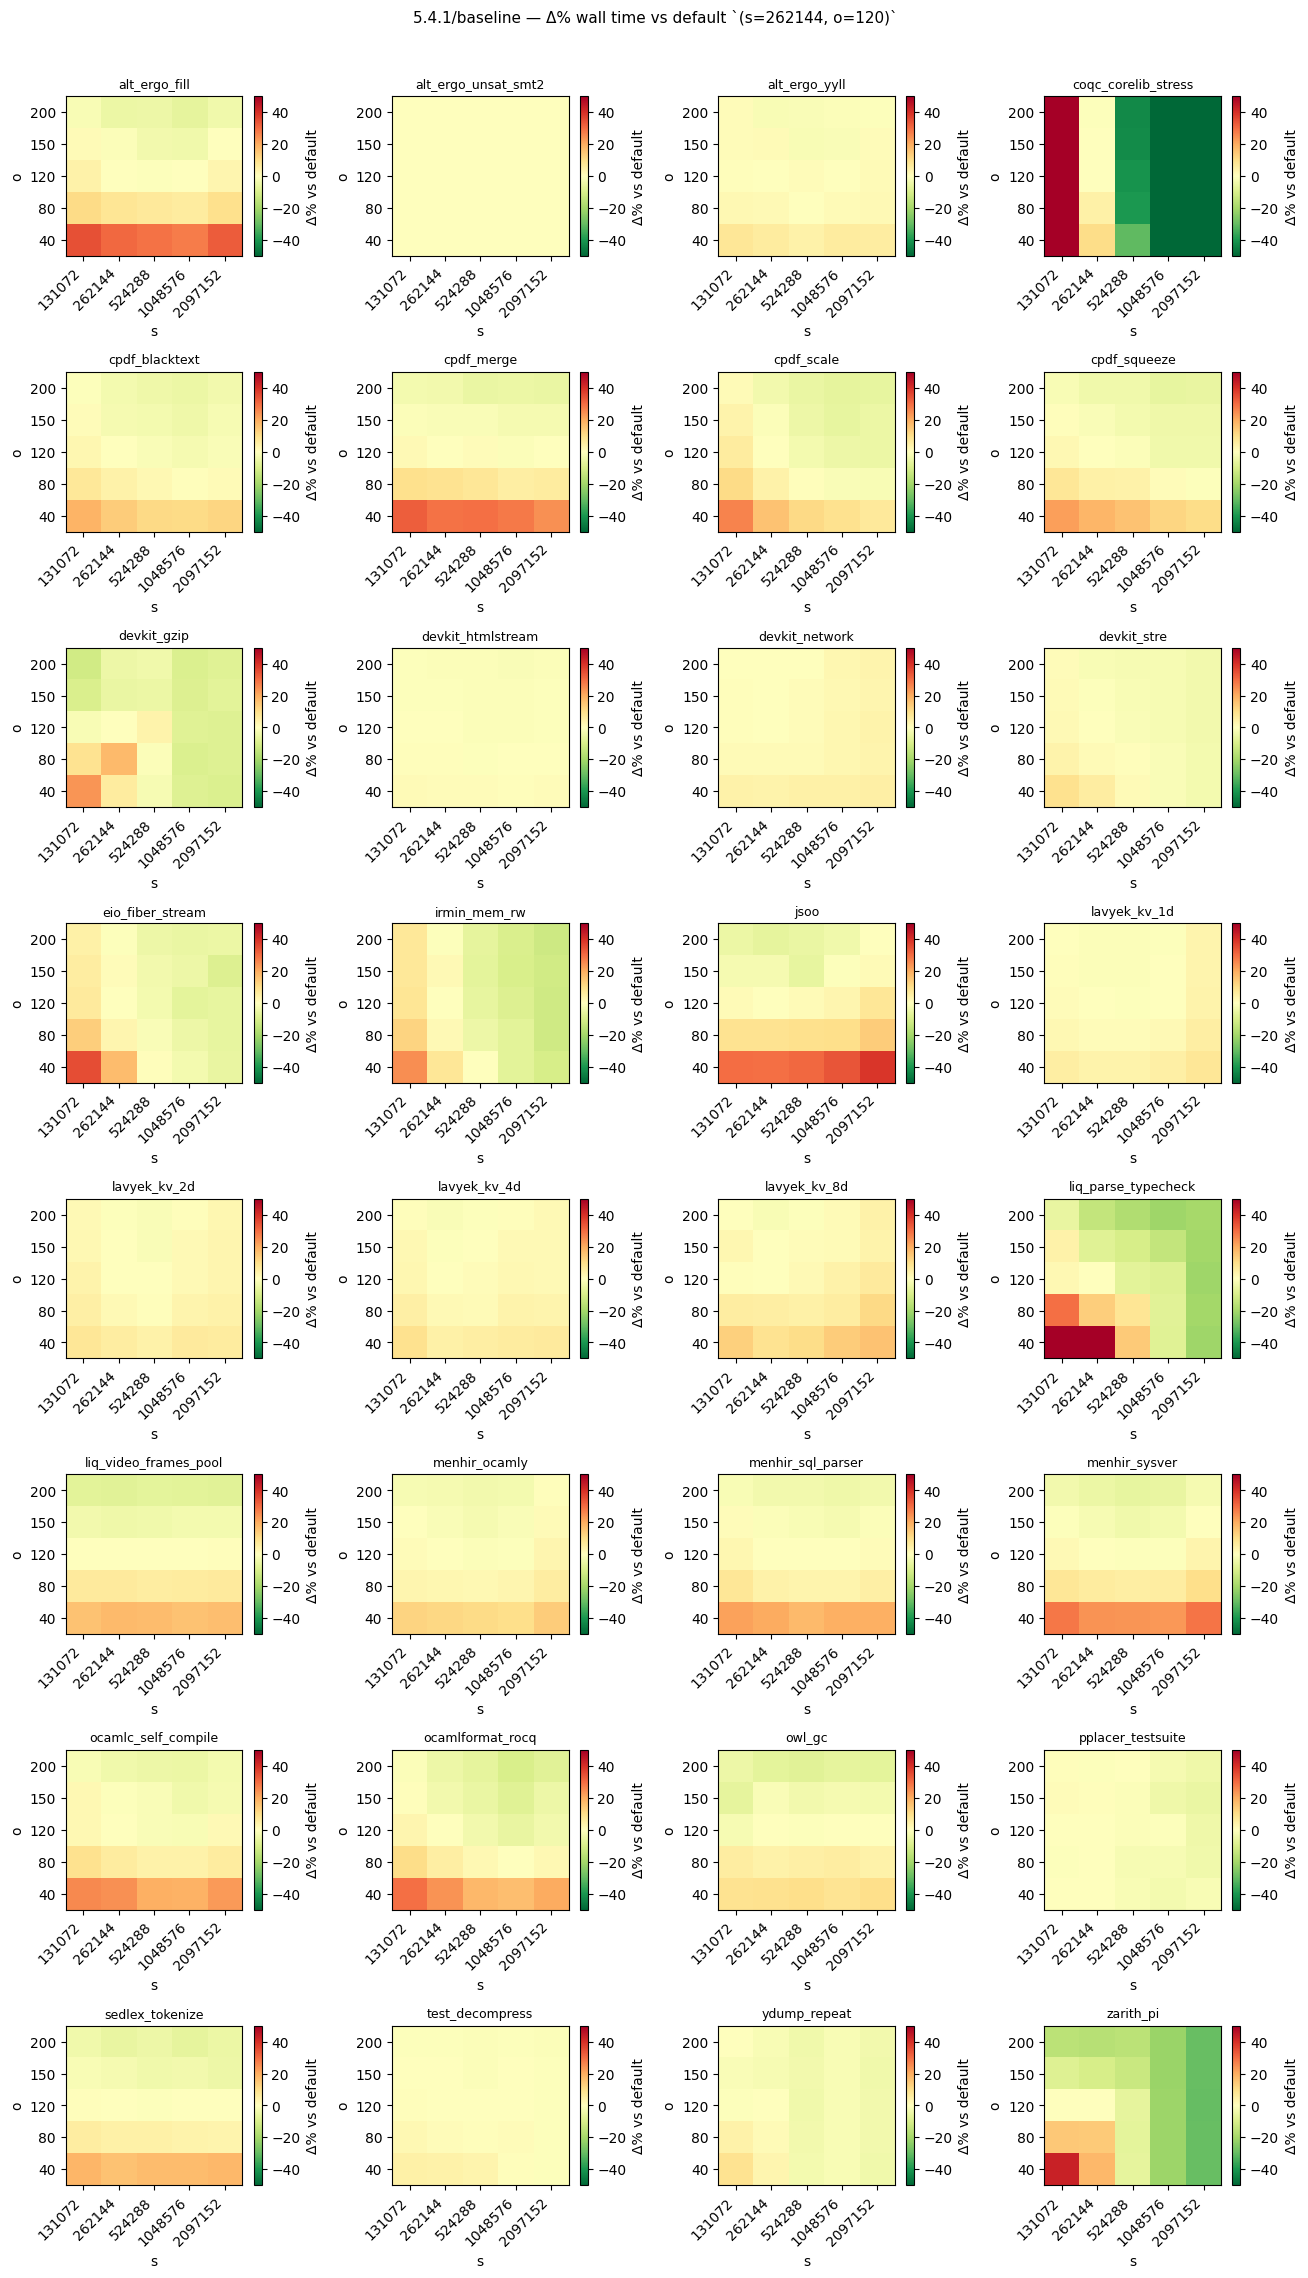

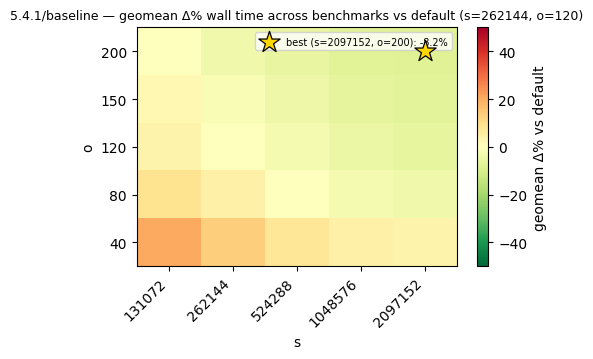

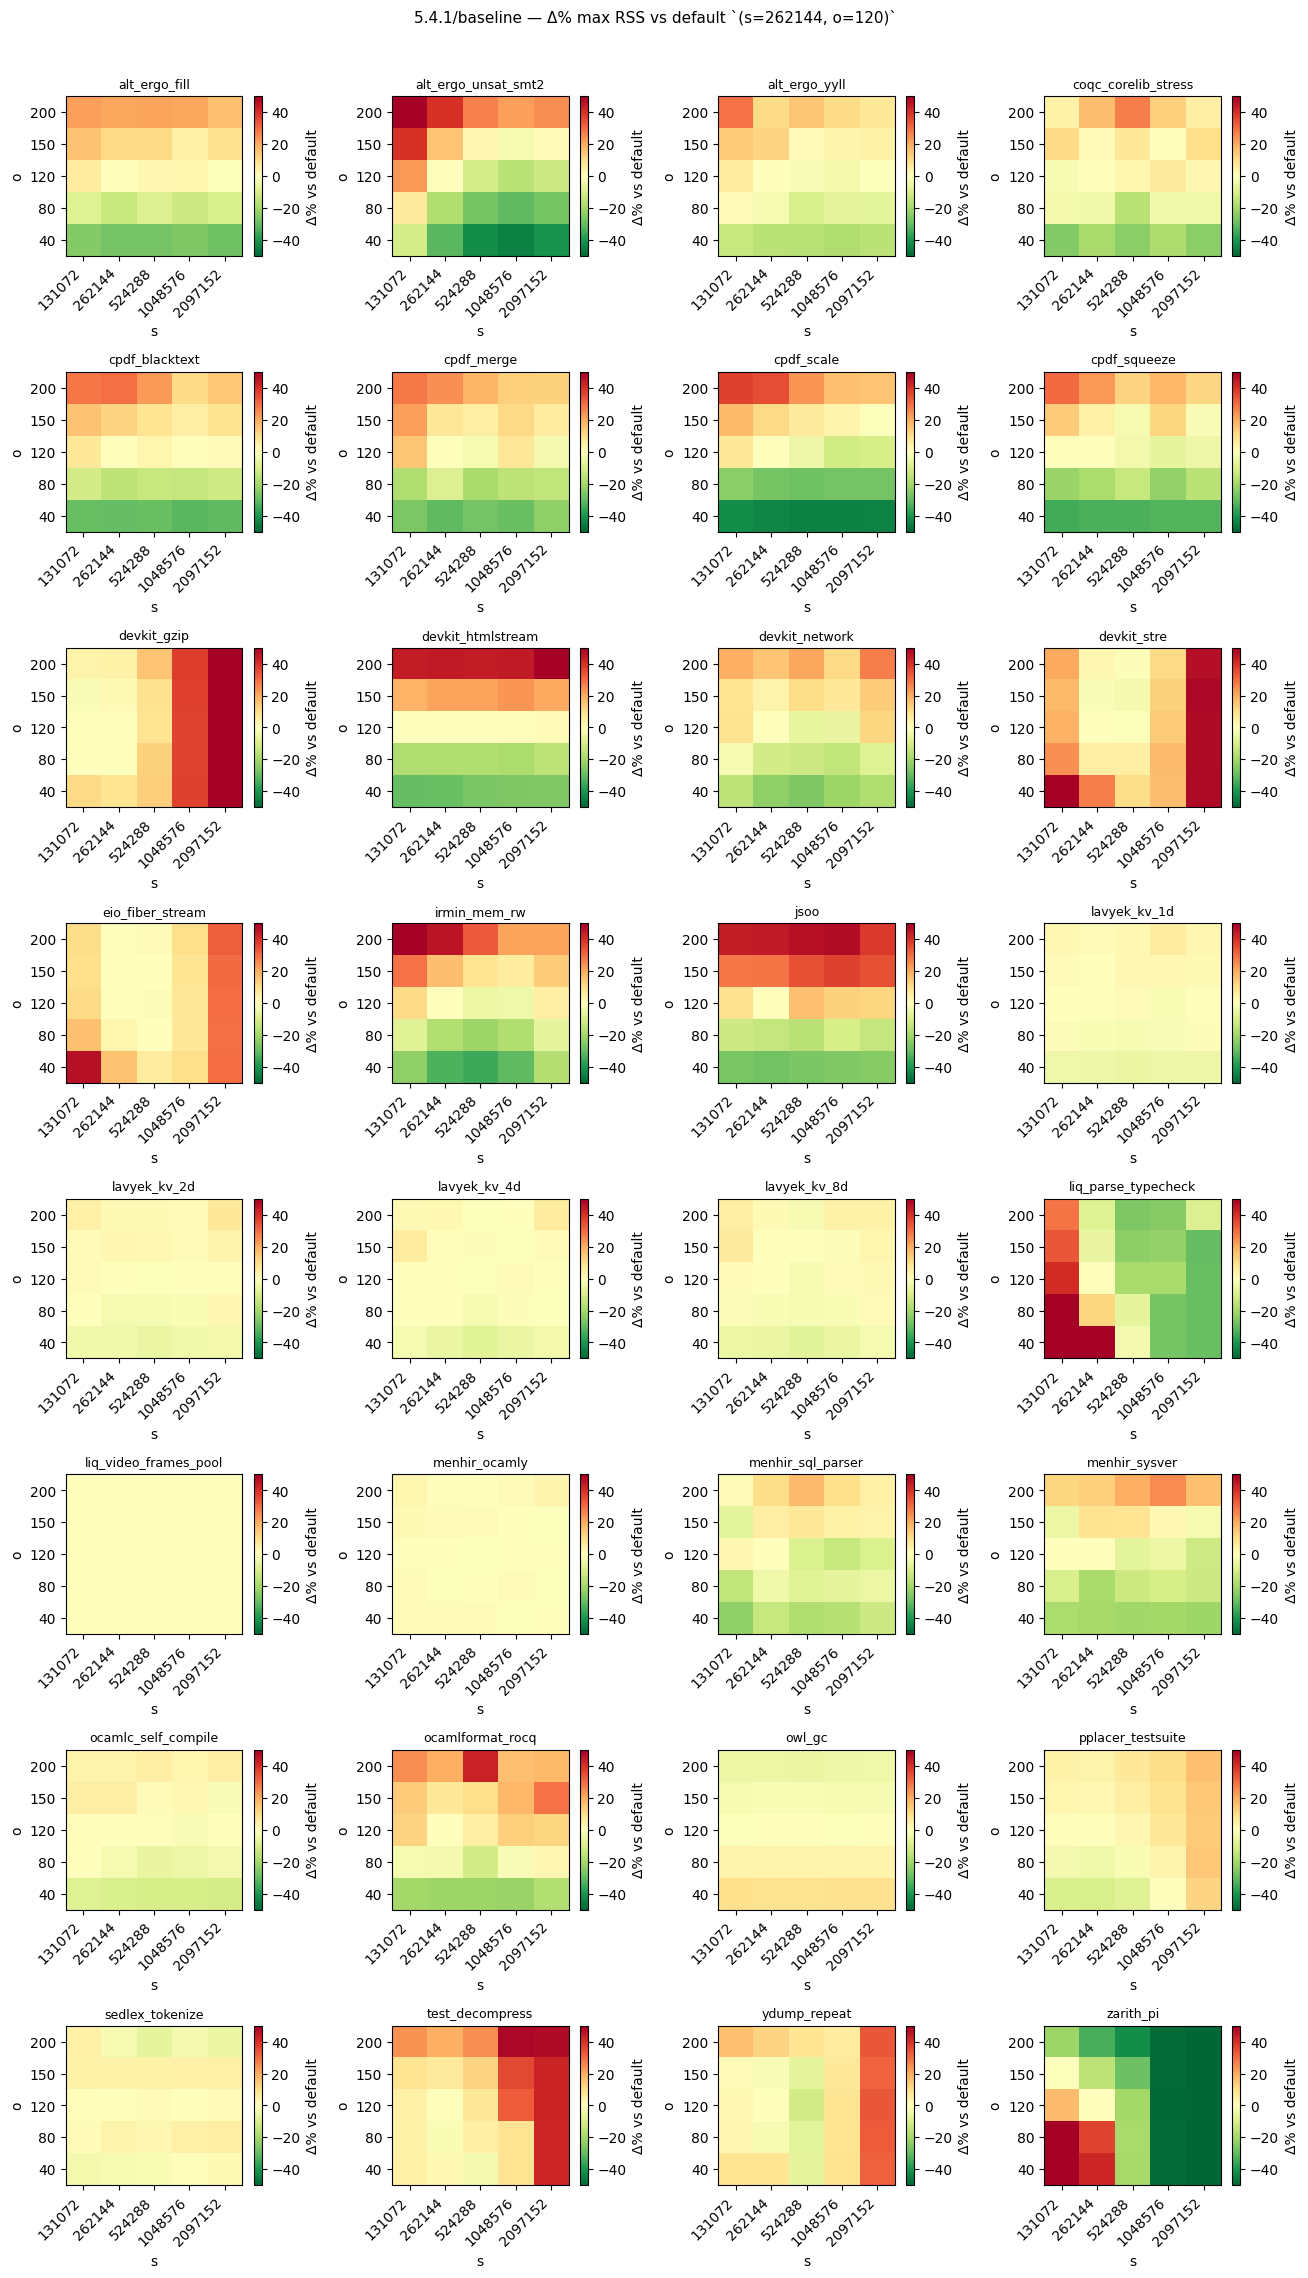

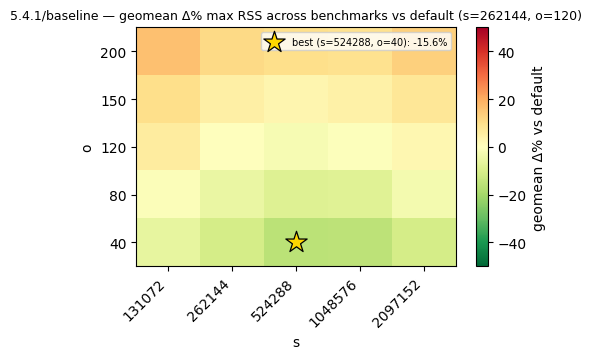

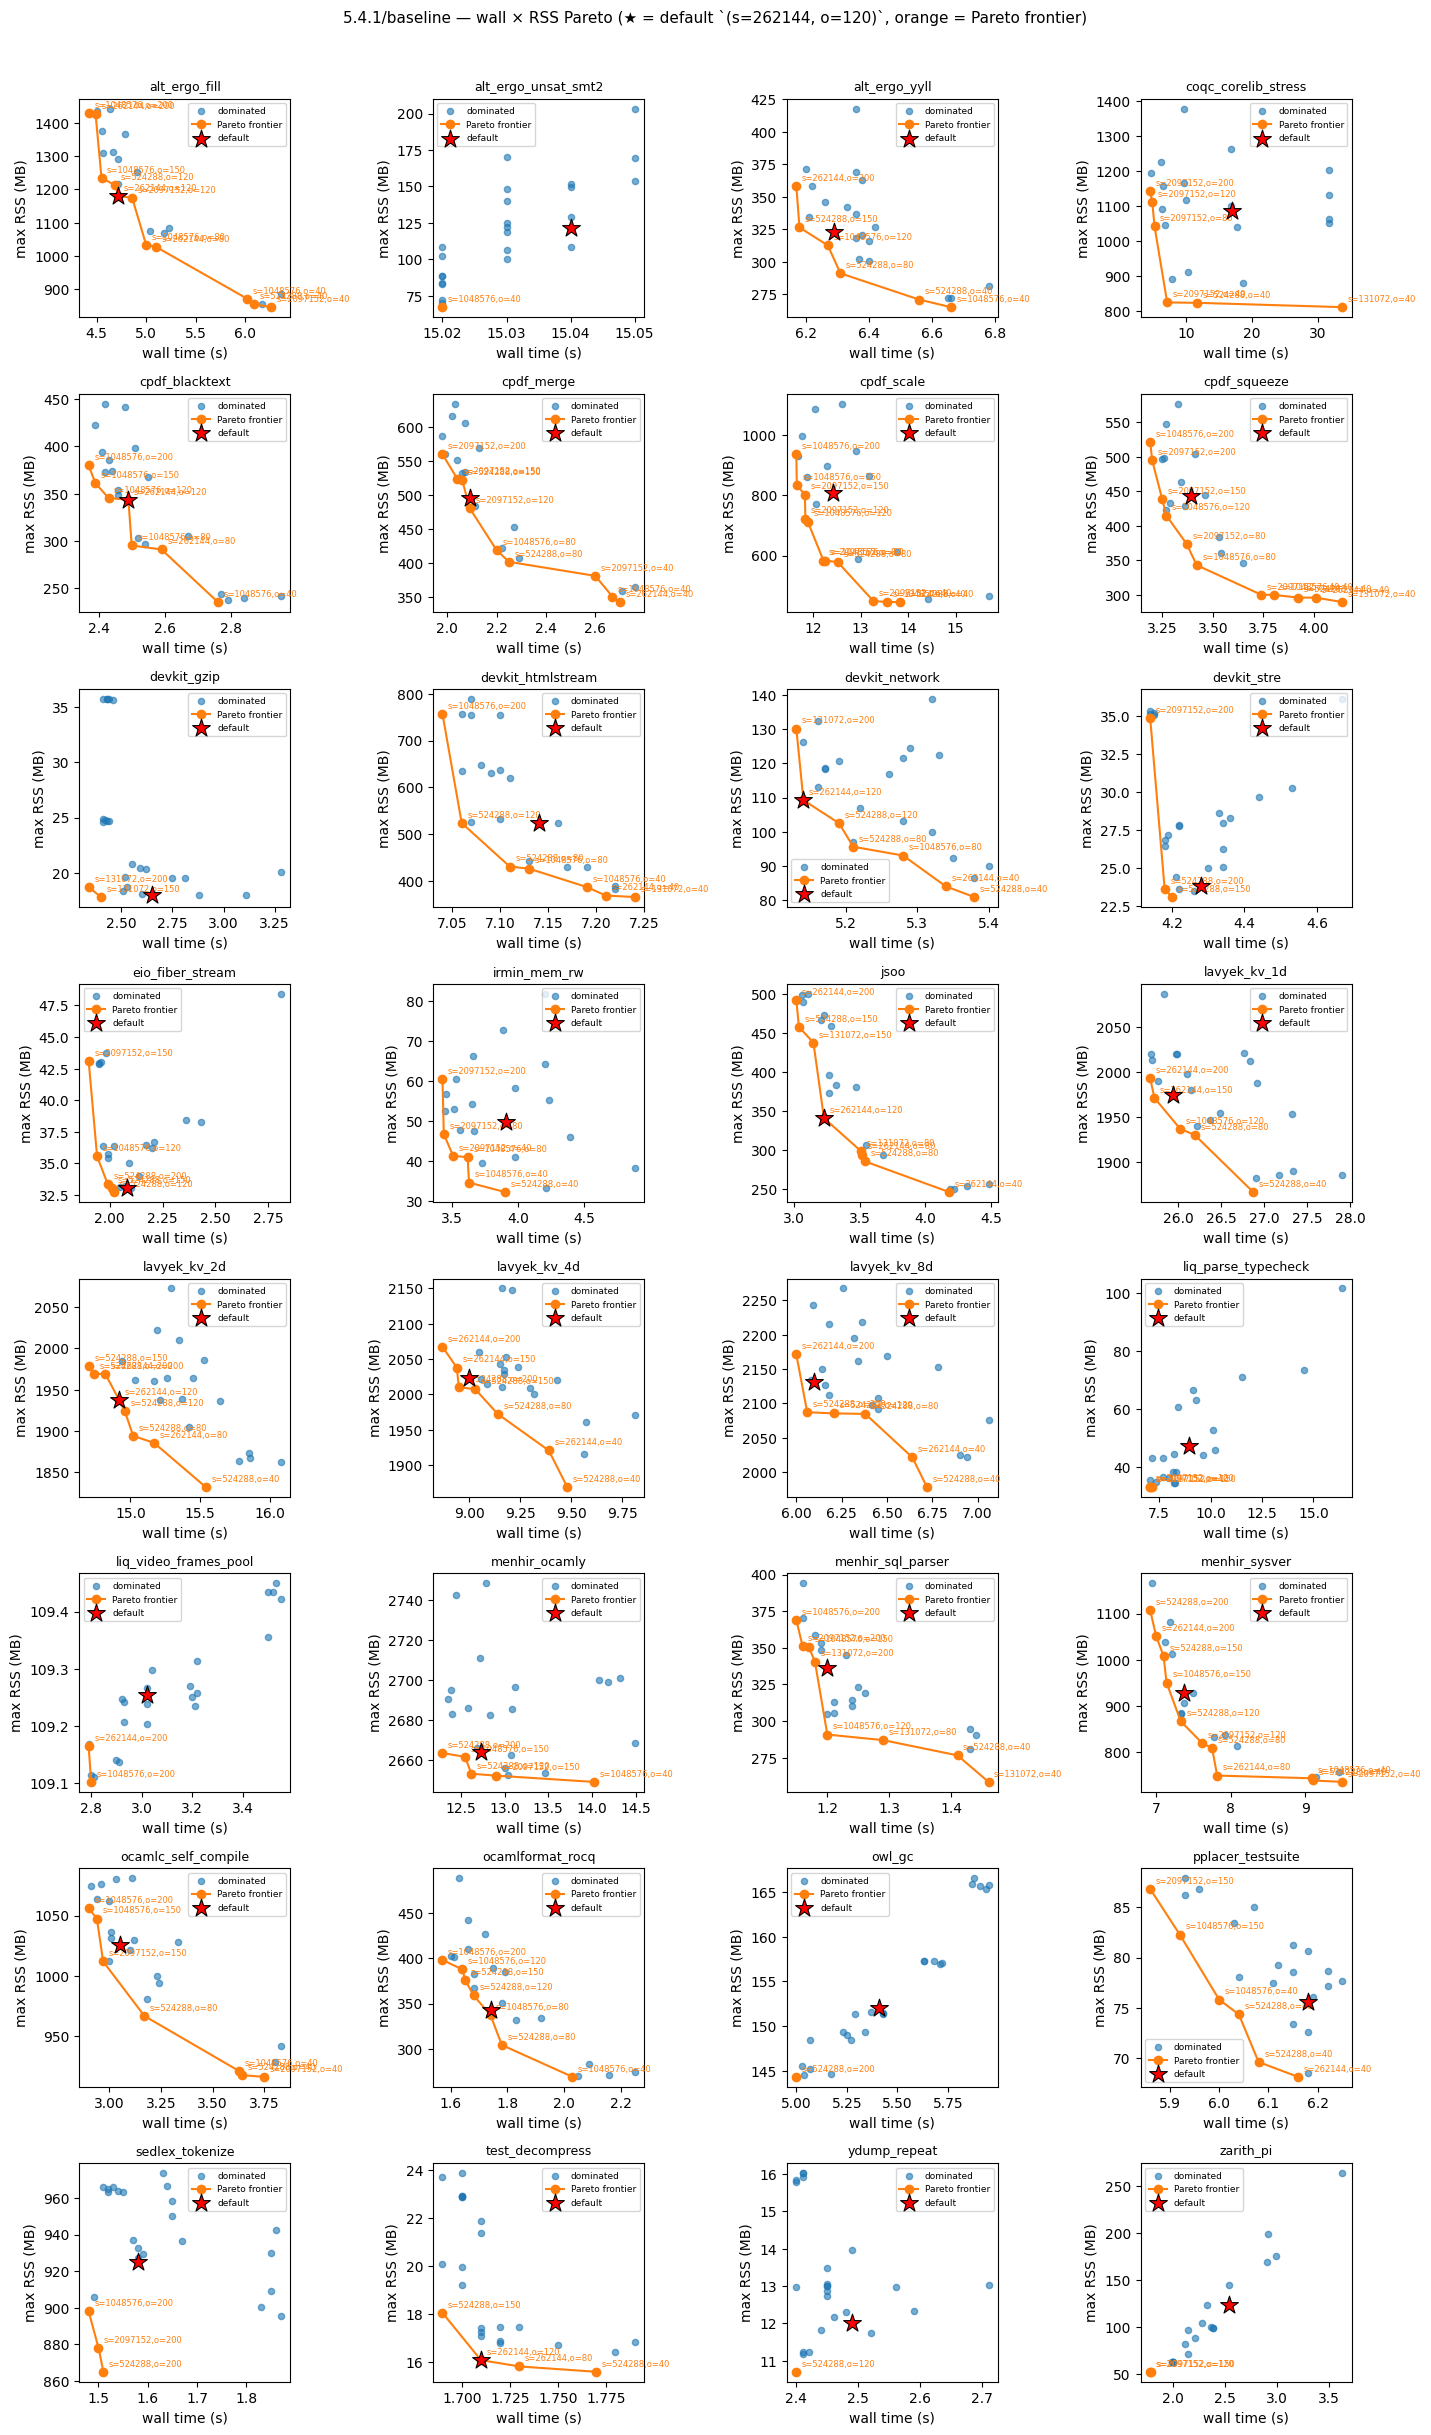

### `d8bb46c/baseline` — axes ['s', 'o'] (varying: ['s', 'o'], fixed: —)

**Default cell:** `(s=262144, o=120)` — all Δ%s in this section are vs this cell.

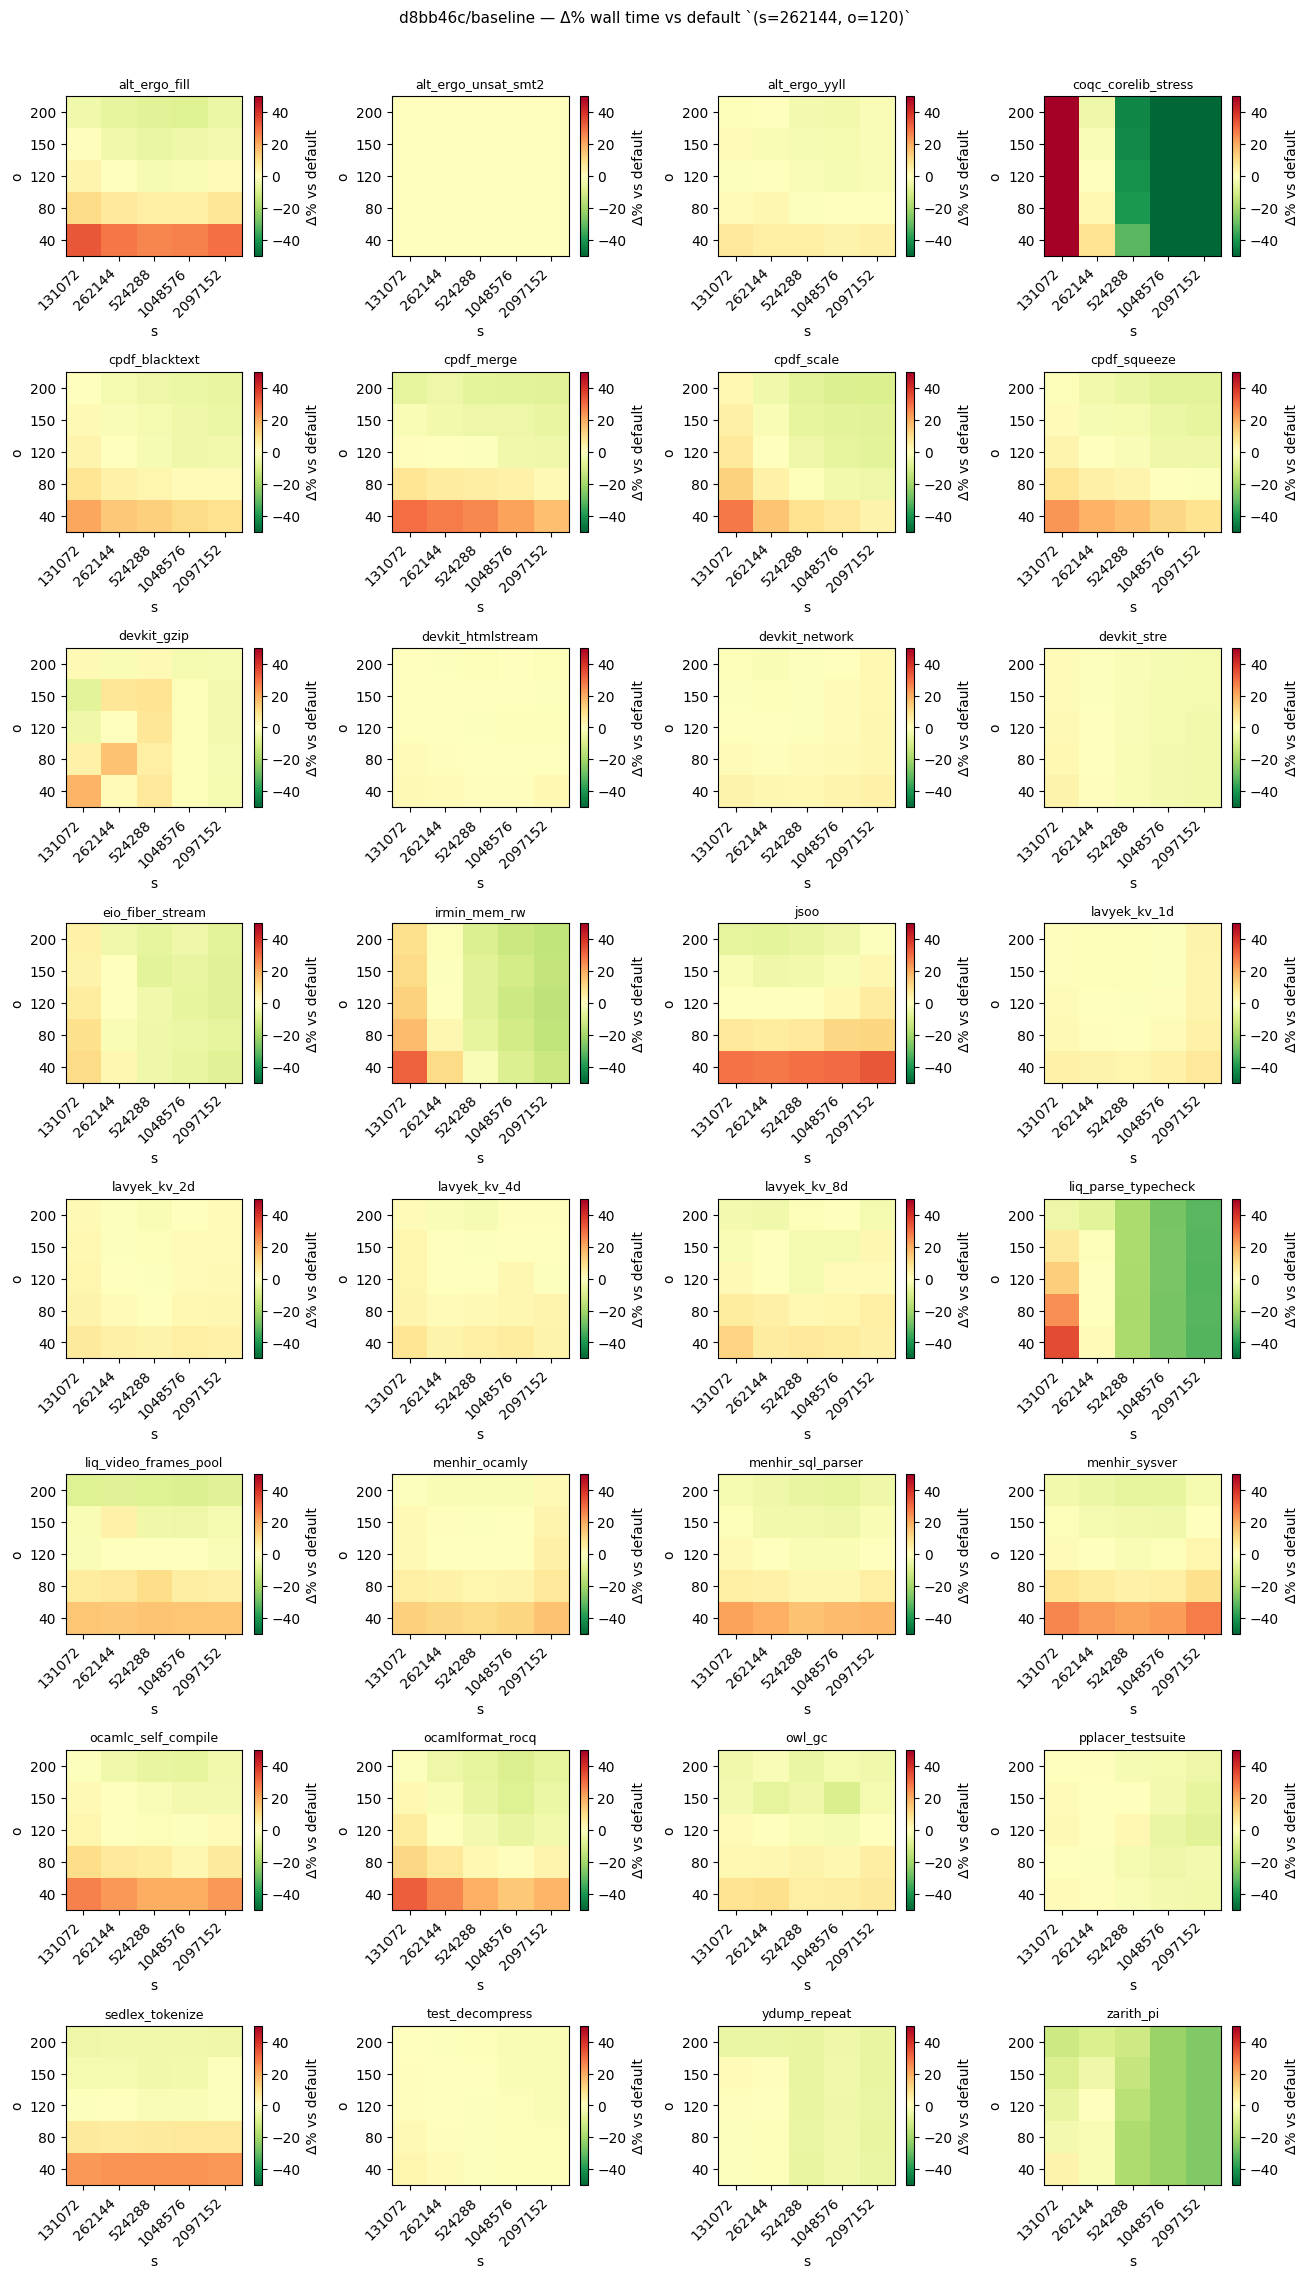

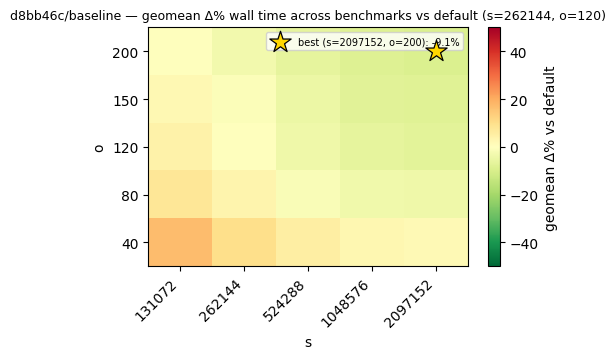

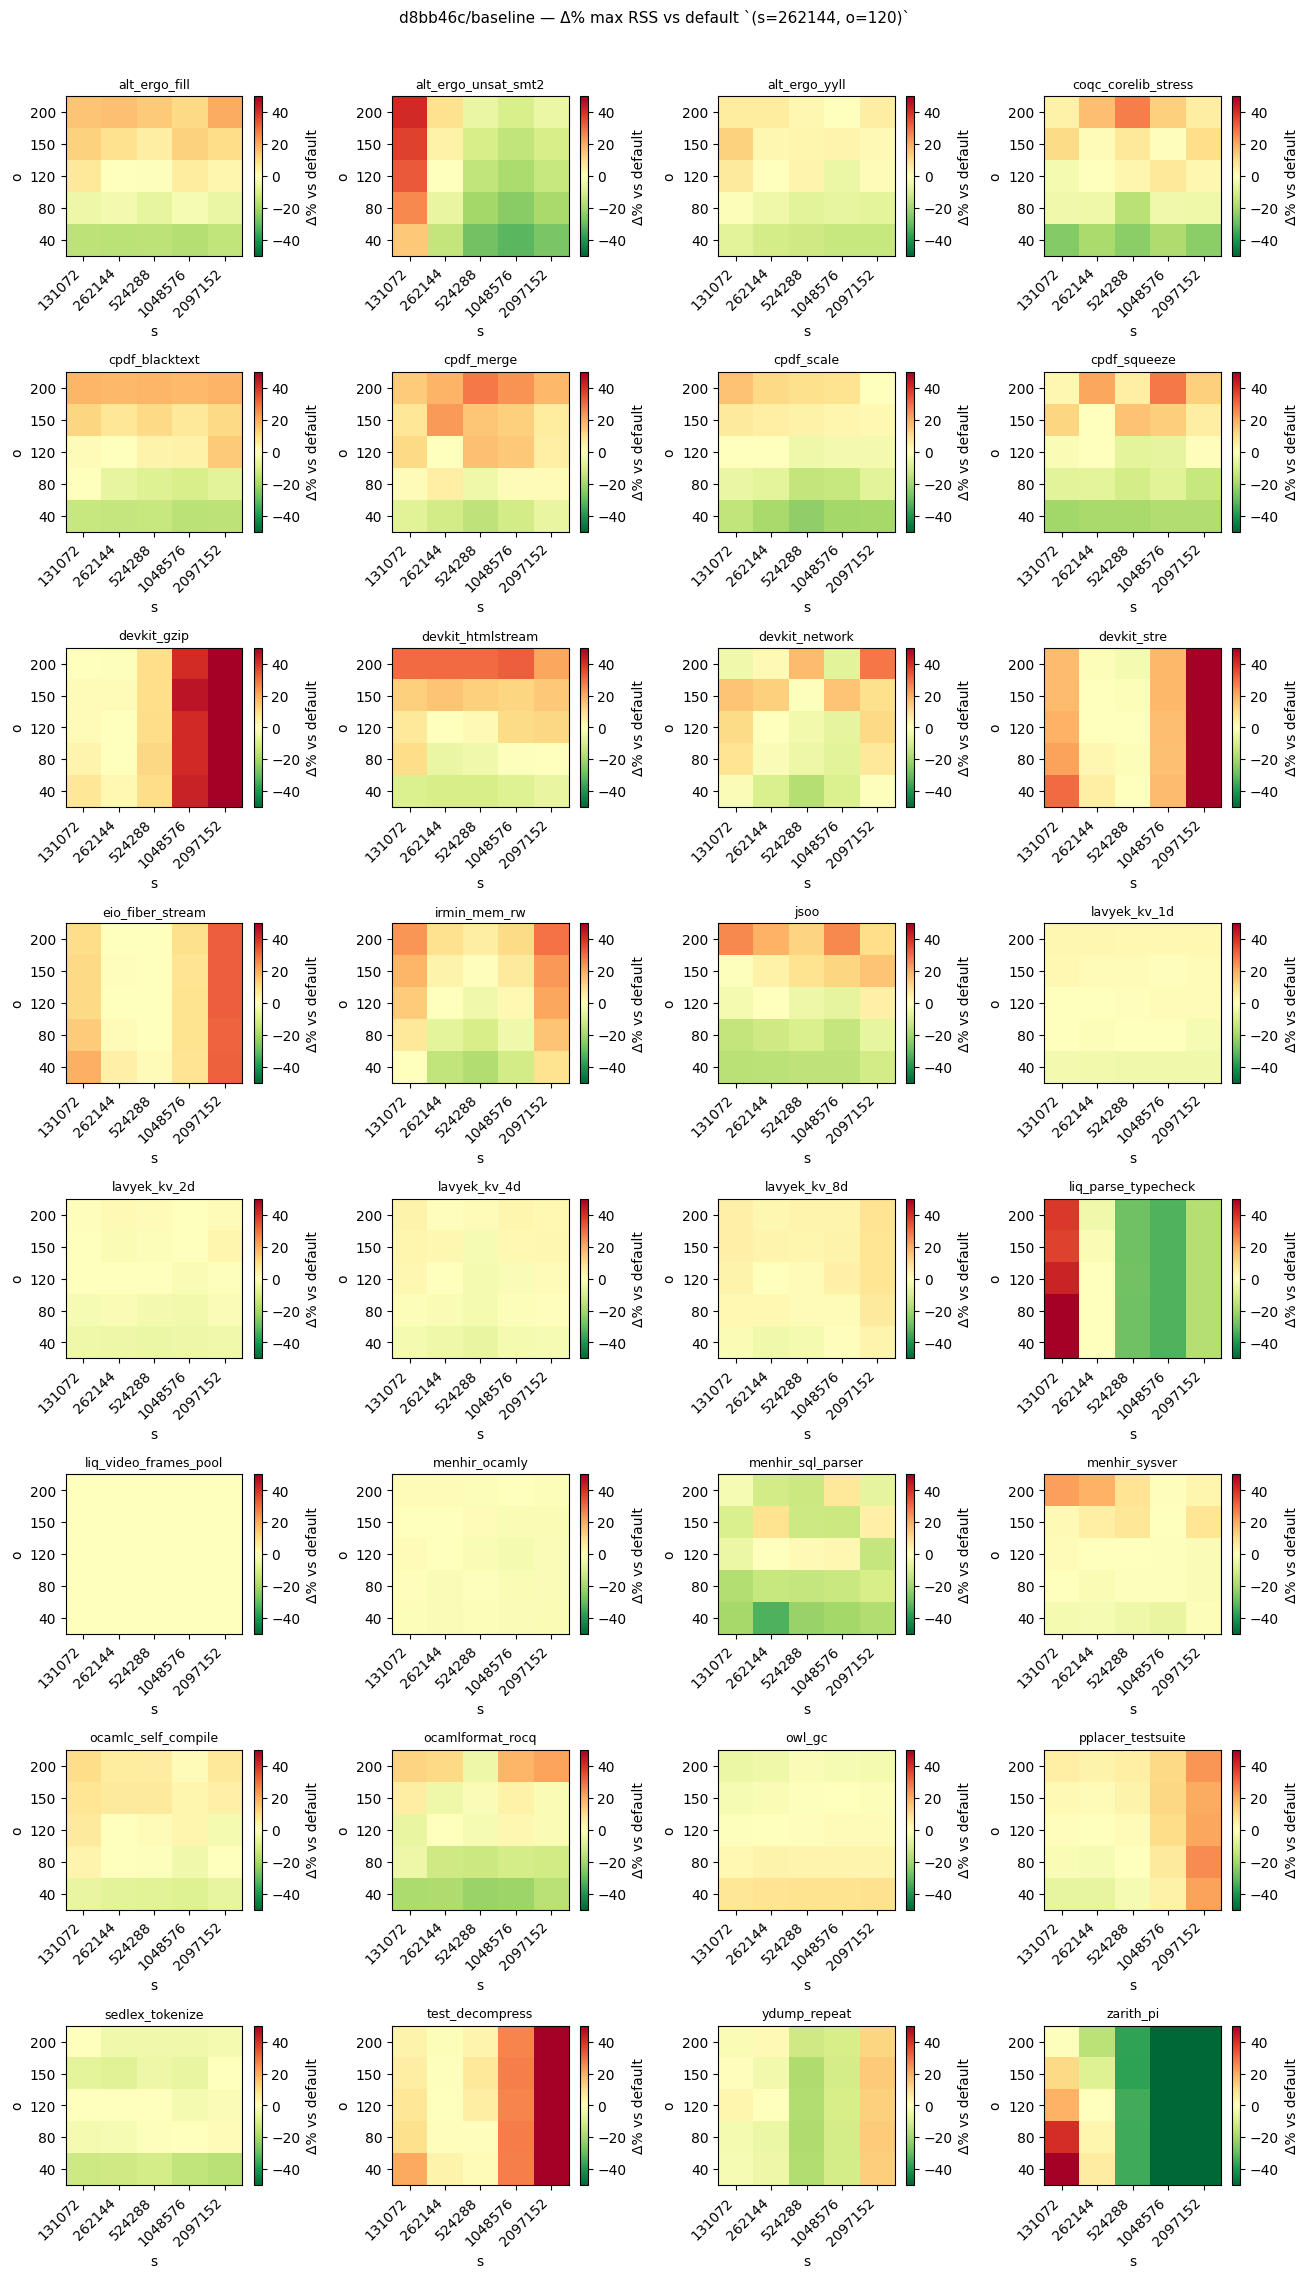

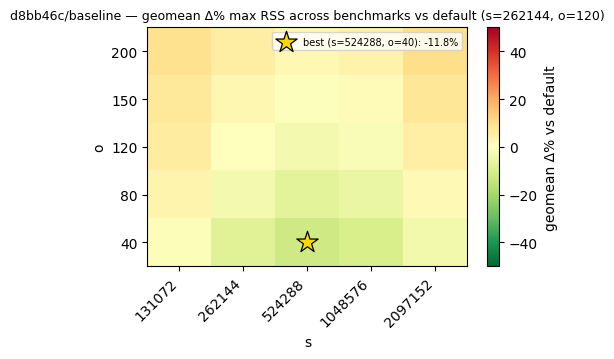

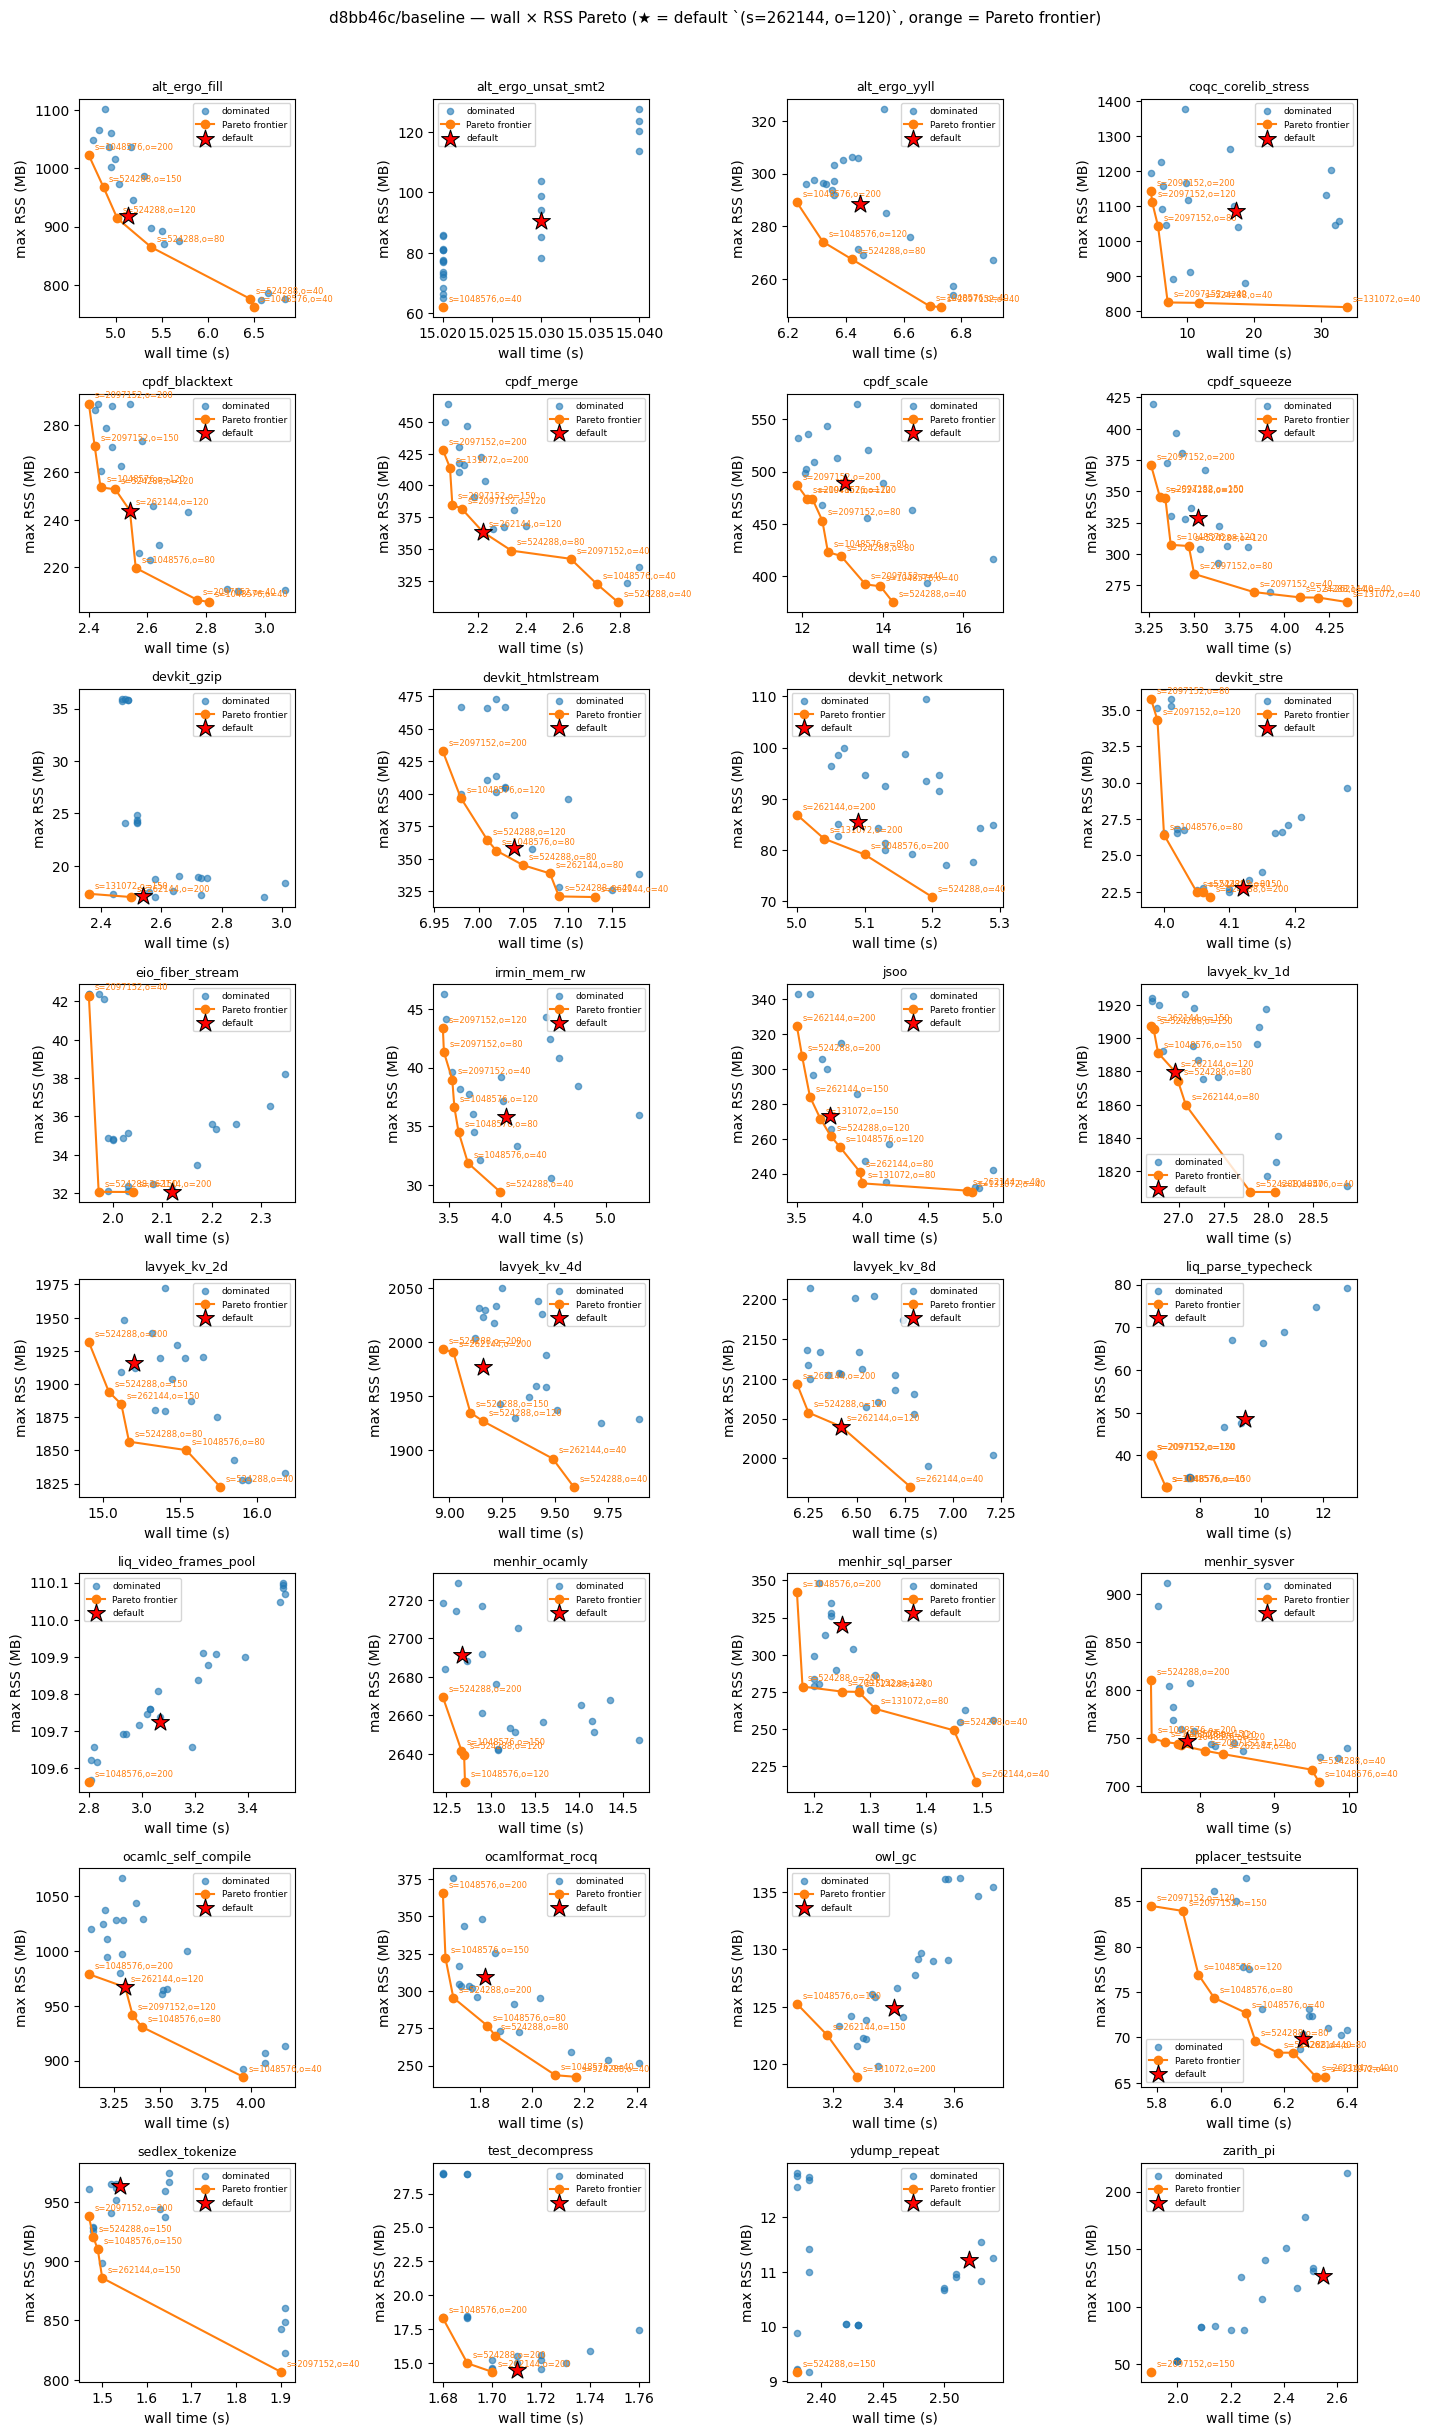

Q1 export rows: 3200


In [5]:
def _aggregate(sub: pd.DataFrame, varying: list[str], metric: str) -> pd.DataFrame:
    """Median of `metric` per (benchmark, *varying axes)."""
    keys = ["benchmark", *varying]
    return (sub.dropna(subset=[metric])
               .groupby(keys, as_index=False)[metric]
               .median())


def _pareto_mask(times: np.ndarray, rsses: np.ndarray) -> np.ndarray:
    pts = np.column_stack([times, rsses])
    n = len(pts)
    mask = np.ones(n, bool)
    for i in range(n):
        dominators = (np.all(pts <= pts[i], axis=1)
                      & np.any(pts <  pts[i], axis=1))
        if dominators.any():
            mask[i] = False
    return mask


def _heatmap_axes(sub: pd.DataFrame, varying: list[str]) -> tuple[list[str], dict]:
    """Pick the two axes with the most unique values; pin the rest at their majority value."""
    if len(varying) <= 2:
        return varying, {}
    counts = {ax: sub[ax].nunique() for ax in varying}
    chosen = sorted(varying, key=lambda a: counts[a], reverse=True)[:2]
    pin_vals = {a: sub[a].mode().iloc[0] for a in varying if a not in chosen}
    return chosen, pin_vals


def _diverging_pcm(ax, grid: pd.DataFrame, title: str, xlabel: str, ylabel: str,
                   max_abs_pct: float, cbar_label: str = "Δ% vs default"):
    z = grid.to_numpy(dtype=float)
    norm = mcolors.TwoSlopeNorm(vmin=-max_abs_pct, vcenter=0.0, vmax=max_abs_pct)
    pcm = ax.imshow(z, origin="lower", aspect="auto", cmap="RdYlGn_r", norm=norm)
    ax.set_xticks(range(len(grid.columns)))
    ax.set_xticklabels([str(int(c)) for c in grid.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(grid.index)))
    ax.set_yticklabels([str(int(r)) for r in grid.index])
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=9)
    plt.colorbar(pcm, ax=ax, label=cbar_label)


def _intra_default_cell(varying: list[str], sub: pd.DataFrame) -> tuple | None:
    """Return the cell tuple matching GC_DEFAULTS along the varying axes,
    or None if any varying axis lacks its default value in this sub-sweep."""
    out = []
    for ax in varying:
        if ax not in GC_DEFAULTS or GC_DEFAULTS[ax] not in sub[ax].unique():
            return None
        out.append(GC_DEFAULTS[ax])
    return tuple(out)


def render_q1(variant: str, presence: tuple, varying: list[str],
              fixed: dict, sub: pd.DataFrame) -> list[dict]:
    """§3 Q1: render per-benchmark Δ% heatmaps + an across-benchmarks
    geomean overall-picture heatmap + Pareto-with-default-star for one
    (variant, sub-sweep). Returns export rows."""
    fixed_str = ", ".join(f"{k}={int(v)}" for k, v in fixed.items()) or "—"
    display(Markdown(
        f"### `{variant}` — axes {list(presence)} (varying: {varying}, fixed: {fixed_str})"
    ))

    if not varying:
        display(Markdown("*No varying axes in this sub-sweep — nothing to plot.*"))
        return []

    chosen, pin_vals = _heatmap_axes(sub, varying)
    if pin_vals:
        pin_str = ", ".join(f"{k}={int(v)}" for k, v in pin_vals.items())
        display(Markdown(f"> More than 2 varying axes; pinning **{pin_str}** "
                         f"to majority value. Heatmap axes: {chosen}."))
        for k, v in pin_vals.items():
            sub = sub[sub[k] == v]

    default_cell = _intra_default_cell(chosen, sub)
    if default_cell is None:
        missing = [ax for ax in chosen if GC_DEFAULTS.get(ax) not in sub[ax].unique()]
        display(Markdown(
            f"*Default cell for axes `{chosen}` not present in sweep "
            f"(missing default for: {missing}). Skipping Q1 view.*"
        ))
        return []

    cell_str = ", ".join(f"{ax}={int(v)}" for ax, v in zip(chosen, default_cell))
    display(Markdown(f"**Default cell:** `({cell_str})` — all Δ%s in this section are vs this cell."))

    benches_present = sorted(sub["benchmark"].unique())
    n = len(benches_present)
    ncols = min(4, n)
    nrows = (n + ncols - 1) // ncols

    # -- Δ% heatmaps per metric --
    export_rows: list[dict] = []
    for metric, label in [("olly_wall_time_s", "wall time"),
                          ("max_rss_mb", "max RSS")]:
        agg = _aggregate(sub, chosen, metric)
        if agg.empty:
            display(Markdown(f"*No `{metric}` data.*"))
            continue

        default_mask = pd.Series(True, index=agg.index)
        for ax, val in zip(chosen, default_cell):
            default_mask &= (agg[ax] == val)
        default_per_bench = (agg[default_mask]
                             .set_index("benchmark")[metric]
                             .to_dict())

        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.3, nrows * 2.9),
                                 squeeze=False)
        fig.suptitle(f"{variant} — Δ% {label} vs default `({cell_str})`", fontsize=11)
        for i, bench in enumerate(benches_present):
            r, c = divmod(i, ncols)
            ax = axes[r][c]
            cell = agg[agg["benchmark"] == bench]
            ref = default_per_bench.get(bench)
            if cell.empty or ref is None or not np.isfinite(ref) or ref <= 0:
                ax.text(0.5, 0.5, "no default", ha="center", va="center")
                ax.set_axis_off()
                continue
            cell = cell.copy()
            cell["delta_pct"] = (cell[metric] / ref - 1) * 100
            grid = cell.pivot(index=chosen[1], columns=chosen[0],
                              values="delta_pct").sort_index().sort_index(axis=1)
            _diverging_pcm(ax, grid, bench, chosen[0], chosen[1],
                           INTRA_DEFAULT_MAX_PCT)
            for _, row in cell.iterrows():
                export_rows.append({
                    "variant": variant,
                    "axes": ",".join(presence),
                    "varying": ",".join(varying),
                    "default_cell": cell_str,
                    "metric": metric,
                    "benchmark": bench,
                    **{ax: int(row[ax]) for ax in chosen},
                    "delta_pct": float(row["delta_pct"]),
                    "value": float(row[metric]),
                    "default_value": float(ref),
                })
        for j in range(n, nrows * ncols):
            r, c = divmod(j, ncols)
            axes[r][c].set_axis_off()
        fig.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

        # -- Overall picture: geomean Δ% across benchmarks per cell --
        # Same shape as §5's cross-runtime aggregate heatmap, but here the
        # ratio is intra-runtime: each benchmark's value at a cell divided
        # by that same benchmark's value at the runtime's default cell.
        # The cell minimising the geomean is starred — the "best
        # configuration" for this metric across the full benchmark set.
        geo_input = agg[agg["benchmark"].isin(default_per_bench.keys())].assign(
            ratio=lambda d: d.apply(
                lambda r: (r[metric] / default_per_bench[r["benchmark"]])
                          if default_per_bench.get(r["benchmark"], 0) > 0
                          else np.nan, axis=1)
        ).dropna(subset=["ratio"])
        if not geo_input.empty:
            geo_input["log_ratio"] = np.log(geo_input["ratio"])
            geo = (geo_input.groupby(chosen, as_index=False)["log_ratio"]
                            .mean())
            geo["geo_delta_pct"] = (np.exp(geo["log_ratio"]) - 1.0) * 100.0
            if len(chosen) == 2:
                grid = (geo.pivot(index=chosen[1], columns=chosen[0],
                                  values="geo_delta_pct")
                            .sort_index().sort_index(axis=1))
                fig, ax = plt.subplots(figsize=(5.0, 3.7))
                _diverging_pcm(ax, grid,
                               f"{variant} — geomean Δ% {label} across "
                               f"benchmarks vs default ({cell_str})",
                               chosen[0], chosen[1], INTRA_DEFAULT_MAX_PCT,
                               cbar_label="geomean Δ% vs default")
                best_row, best_col = grid.stack().idxmin()
                yi = list(grid.index).index(best_row)
                xi = list(grid.columns).index(best_col)
                ax.scatter([xi], [yi], marker="*", s=260, c="gold",
                           edgecolors="black", linewidths=0.9, zorder=6,
                           label=(f"best ({chosen[0]}={int(best_col)}, "
                                  f"{chosen[1]}={int(best_row)}): "
                                  f"{grid.loc[best_row, best_col]:+.1f}%"))
                ax.legend(fontsize=7, loc="best")
                fig.tight_layout()
                plt.show()
            elif len(chosen) == 1:
                fig, ax = plt.subplots(figsize=(5.0, 3.0))
                ax.axhline(0.0, color="gray", lw=0.5)
                xs = geo[chosen[0]].to_numpy()
                ys = geo["geo_delta_pct"].to_numpy()
                order = np.argsort(xs)
                ax.plot(xs[order], ys[order], "o-")
                best_i = int(np.argmin(ys))
                ax.scatter([xs[best_i]], [ys[best_i]], marker="*", s=240,
                           c="gold", edgecolors="black", linewidths=0.9,
                           zorder=6,
                           label=f"best {chosen[0]}={int(xs[best_i])}: "
                                 f"{ys[best_i]:+.1f}%")
                ax.set_xlabel(chosen[0])
                ax.set_ylabel("geomean Δ% vs default")
                ax.set_title(f"{variant} — geomean Δ% {label} across benchmarks")
                ax.legend(fontsize=7, loc="best")
                fig.tight_layout()
                plt.show()

    # -- Pareto scatter (wall × RSS) with default starred + frontier labelled --
    agg_t = _aggregate(sub, chosen, "olly_wall_time_s")
    agg_r = _aggregate(sub, chosen, "max_rss_mb")
    agg = agg_t.merge(agg_r, on=["benchmark", *chosen], how="inner")
    if agg.empty:
        return export_rows

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.6, nrows * 3.1),
                             squeeze=False)
    fig.suptitle(f"{variant} — wall × RSS Pareto "
                 f"(★ = default `({cell_str})`, orange = Pareto frontier)",
                 fontsize=11)
    for i, bench in enumerate(benches_present):
        r, c = divmod(i, ncols)
        ax = axes[r][c]
        cell = agg[agg["benchmark"] == bench].reset_index(drop=True)
        if cell.empty:
            ax.text(0.5, 0.5, "no data", ha="center", va="center")
            ax.set_axis_off()
            continue
        t = cell["olly_wall_time_s"].to_numpy()
        rs = cell["max_rss_mb"].to_numpy()
        mask = _pareto_mask(t, rs)
        # All dominated points in blue
        ax.scatter(t[~mask], rs[~mask], s=20, c="C0", alpha=0.6, label="dominated")
        # Pareto frontier in orange, line+markers
        front = np.argsort(t[mask])
        ax.plot(t[mask][front], rs[mask][front], "o-", c="C1",
                markersize=6, label="Pareto frontier")
        # Label each frontier point with its config
        cell_vals = cell[chosen].to_numpy()
        frontier_idx = np.flatnonzero(mask)[front]
        for px, py, idx in zip(t[mask][front], rs[mask][front], frontier_idx):
            label_txt = ",".join(f"{ax_name}={int(v)}"
                                 for ax_name, v in zip(chosen, cell_vals[idx]))
            ax.annotate(label_txt, (px, py), fontsize=6,
                        xytext=(4, 4), textcoords="offset points", color="C1")
        # Star the default cell — find it in this bench's data
        default_row = cell
        for ax_name, val in zip(chosen, default_cell):
            default_row = default_row[default_row[ax_name] == val]
        if not default_row.empty:
            dx = default_row["olly_wall_time_s"].iloc[0]
            dy = default_row["max_rss_mb"].iloc[0]
            ax.scatter([dx], [dy], marker="*", s=180, c="red",
                       edgecolors="black", linewidths=0.8, zorder=5,
                       label=f"default")
        ax.set_title(bench, fontsize=9)
        ax.set_xlabel("wall time (s)")
        ax.set_ylabel("max RSS (MB)")
        ax.legend(fontsize=6.5, loc="best")
    for j in range(n, nrows * ncols):
        r, c = divmod(j, ncols)
        axes[r][c].set_axis_off()
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

    return export_rows


intra_rows: list[dict] = []
for variant, presence, varying, fixed, sub in sub_sweeps:
    intra_rows.extend(render_q1(variant, presence, varying, fixed, sub))

print(f"Q1 export rows: {len(intra_rows)}")


## 4. Q3 — Aggregate new-default candidates

*The "ship-or-not" question.* For each (variant, sub-sweep) the
notebook ranks candidate cells by their geomean Δ% across all
benchmarks vs the **current default cell** (from `GC_DEFAULTS` in §1).

For each candidate cell it reports:

- **geomean wall Δ%** — what the typical user gains/loses
- **geomean RSS Δ%** — same for memory
- **worst per-bench wall Δ%** — and which bench would regress most
- **worst per-bench RSS Δ%** — same for RSS
- **improve / regress counts** — how many benchmarks improve vs regress

Two rankings are produced, side-by-side:

- **Unfiltered top picks** — three candidates by:
  - lowest geomean wall (= biggest typical wall improvement)
  - lowest geomean RSS (= biggest typical RSS improvement)
  - lowest geomean Pareto (= biggest balanced improvement,
    minimising `√(wall_ratio × rss_ratio)`)
- **Safety-filtered top picks** — same three picks, but restricted to
  candidates where **no single benchmark regresses by more than
  `MAX_REGRESSION_PCT`** (default 10%) on either wall or RSS. This is
  the recommendation suitable for shipping as a new default.

If the safety filter is too tight (zero candidates pass), the notebook
reports that and prints the relaxed threshold that would have admitted
at least one candidate, so you know how close you came.


In [6]:
def _geomean(xs: np.ndarray) -> float:
    xs = np.asarray(xs, dtype=float)
    xs = xs[np.isfinite(xs) & (xs > 0)]
    if len(xs) == 0:
        return float("nan")
    return float(np.exp(np.mean(np.log(xs))))


def candidates_vs_default(sub: pd.DataFrame, varying: list[str]):
    """For each cell in the sub-sweep, compute aggregate metrics relative to
    the runtime's default cell. Returns a DataFrame with one row per cell.

    Columns: varying axes, geomean_wall_pct, geomean_rss_pct, geomean_pareto_pct,
    worst_wall_pct, worst_wall_bench, worst_rss_pct, worst_rss_bench,
    n_improve_wall, n_regress_wall, n_improve_rss, n_regress_rss.
    """
    if not varying:
        return None
    default = _intra_default_cell(varying, sub)
    if default is None:
        return None

    agg_t = _aggregate(sub, varying, "olly_wall_time_s")
    agg_r = _aggregate(sub, varying, "max_rss_mb")
    if agg_t.empty or agg_r.empty:
        return None

    # Per-benchmark default value
    def_mask_t = pd.Series(True, index=agg_t.index)
    def_mask_r = pd.Series(True, index=agg_r.index)
    for ax, val in zip(varying, default):
        def_mask_t &= (agg_t[ax] == val)
        def_mask_r &= (agg_r[ax] == val)
    def_wall = agg_t[def_mask_t].set_index("benchmark")["olly_wall_time_s"].to_dict()
    def_rss  = agg_r[def_mask_r].set_index("benchmark")["max_rss_mb"].to_dict()

    # Per-bench ratio at every cell
    agg_t = agg_t.assign(wall_ratio=agg_t.apply(
        lambda r: r["olly_wall_time_s"] / def_wall[r["benchmark"]]
                   if def_wall.get(r["benchmark"], 0) > 0 else np.nan, axis=1))
    agg_r = agg_r.assign(rss_ratio=agg_r.apply(
        lambda r: r["max_rss_mb"] / def_rss[r["benchmark"]]
                   if def_rss.get(r["benchmark"], 0) > 0 else np.nan, axis=1))

    joined = agg_t.merge(agg_r, on=["benchmark", *varying], how="inner")

    rows = []
    for cell_tuple, g in joined.groupby(varying):
        if not isinstance(cell_tuple, tuple):
            cell_tuple = (cell_tuple,)
        wr = g["wall_ratio"].to_numpy()
        rr = g["rss_ratio"].to_numpy()
        ww = _geomean(wr); rg = _geomean(rr)
        pareto = np.sqrt(ww * rg) if np.isfinite(ww) and np.isfinite(rg) else np.nan
        worst_wall_i = g["wall_ratio"].idxmax()
        worst_rss_i  = g["rss_ratio"].idxmax()
        rows.append({
            **{ax: int(v) for ax, v in zip(varying, cell_tuple)},
            "geomean_wall_pct":   (ww - 1.0) * 100,
            "geomean_rss_pct":    (rg - 1.0) * 100,
            "geomean_pareto_pct": (pareto - 1.0) * 100,
            "worst_wall_pct":     (g.loc[worst_wall_i, "wall_ratio"] - 1.0) * 100,
            "worst_wall_bench":   g.loc[worst_wall_i, "benchmark"],
            "worst_rss_pct":      (g.loc[worst_rss_i, "rss_ratio"] - 1.0) * 100,
            "worst_rss_bench":    g.loc[worst_rss_i, "benchmark"],
            "n_improve_wall":     int((wr < 1.0).sum()),
            "n_regress_wall":     int((wr > 1.0).sum()),
            "n_improve_rss":      int((rr < 1.0).sum()),
            "n_regress_rss":      int((rr > 1.0).sum()),
        })
    return pd.DataFrame(rows), default


def _pick_three(df: pd.DataFrame, varying: list[str]) -> pd.DataFrame:
    """Return three rows: best wall, best RSS, best Pareto."""
    if df.empty:
        return df
    picks = []
    for kind, col in [("best wall", "geomean_wall_pct"),
                      ("best RSS", "geomean_rss_pct"),
                      ("best Pareto", "geomean_pareto_pct")]:
        i = df[col].idxmin()
        picks.append({"kind": kind, **df.loc[i].to_dict()})
    out = pd.DataFrame(picks)
    # Reorder columns: kind, varying, metrics
    leading = ["kind", *varying]
    rest = [c for c in out.columns if c not in leading]
    return out[leading + rest]


def _is_safe(row: pd.Series, max_regression_pct: float) -> bool:
    return (row["worst_wall_pct"] <= max_regression_pct
            and row["worst_rss_pct"] <= max_regression_pct)


def _fmt_pct(x):
    return f"{x:+.1f}%" if pd.notna(x) else "—"


q3_blocks: list[dict] = []
for variant, presence, varying, fixed, sub in sub_sweeps:
    res = candidates_vs_default(sub, varying)
    if res is None:
        continue
    df_cells, default = res
    fixed_str = ", ".join(f"{k}={int(v)}" for k, v in fixed.items()) or "—"
    cell_str = ", ".join(f"{ax}={int(v)}" for ax, v in zip(varying, default))

    display(Markdown(
        f"### `{variant}` — axes {list(presence)} "
        f"(varying: {varying}, fixed: {fixed_str})\n\n"
        f"Default cell: `({cell_str})`. {len(df_cells)} candidate cells "
        f"in this sweep (including the default itself). All Δ%s below "
        f"are **vs the default**."
    ))

    # -- Unfiltered ranking --
    unfiltered = _pick_three(df_cells, varying)
    display(Markdown("**Unfiltered top picks** — purely by aggregate geomean:"))
    display(unfiltered.style.format({
        "geomean_wall_pct": _fmt_pct, "geomean_rss_pct": _fmt_pct,
        "geomean_pareto_pct": _fmt_pct, "worst_wall_pct": _fmt_pct,
        "worst_rss_pct": _fmt_pct,
    }))

    # -- Safety-filtered ranking --
    threshold = MAX_REGRESSION_PCT
    safe = df_cells[df_cells.apply(lambda r: _is_safe(r, threshold), axis=1)]

    if safe.empty:
        # Find a relaxed threshold that would admit at least one candidate.
        worst_at_each = df_cells.apply(
            lambda r: max(r["worst_wall_pct"], r["worst_rss_pct"]), axis=1)
        if (worst_at_each.dropna() > 0).any():
            relaxed = worst_at_each.min()
            display(Markdown(
                f"**Safety-filtered top picks** — *no candidate passes* "
                f"`MAX_REGRESSION_PCT={threshold:.1f}%`. The tightest "
                f"single-bench regression in the entire sweep is "
                f"`{relaxed:+.1f}%` — relax the threshold above that "
                f"to see candidates."
            ))
        else:
            display(Markdown(
                f"**Safety-filtered top picks** — no candidate passes "
                f"`MAX_REGRESSION_PCT={threshold:.1f}%` and no cell shows "
                f"a positive regression. (Investigate the data.)"
            ))
    else:
        safe_picks = _pick_three(safe, varying)
        display(Markdown(
            f"**Safety-filtered top picks** — `MAX_REGRESSION_PCT={threshold:.1f}%` "
            f"(={len(safe)}/{len(df_cells)} candidates pass; no bench regresses "
            f"more than {threshold:.1f}% on either wall or RSS):"
        ))
        display(safe_picks.style.format({
            "geomean_wall_pct": _fmt_pct, "geomean_rss_pct": _fmt_pct,
            "geomean_pareto_pct": _fmt_pct, "worst_wall_pct": _fmt_pct,
            "worst_rss_pct": _fmt_pct,
        }))

    q3_blocks.append({
        "variant": variant,
        "presence": presence,
        "varying": varying,
        "fixed": fixed,
        "default_cell": cell_str,
        "all_cells": df_cells,
        "unfiltered_picks": unfiltered,
        "safe_picks": _pick_three(safe, varying) if not safe.empty else None,
        "threshold": threshold,
    })

print(f"\nQ3 ranked {len(q3_blocks)} (variant, sub-sweep) blocks.")


### `5.4.1/baseline` — axes ['s', 'o'] (varying: ['s', 'o'], fixed: —)

Default cell: `(s=262144, o=120)`. 25 candidate cells in this sweep (including the default itself). All Δ%s below are **vs the default**.

**Unfiltered top picks** — purely by aggregate geomean:

,kind,s,o,geomean_wall_pct,geomean_rss_pct,geomean_pareto_pct,worst_wall_pct,worst_wall_bench,worst_rss_pct,worst_rss_bench,n_improve_wall,n_regress_wall,n_improve_rss,n_regress_rss
0,best wall,2097152,200,-8.2%,+13.1%,+1.9%,+4.3%,lavyek_kv_8d,+98.0%,devkit_gzip,24,6,5,27
1,best RSS,524288,40,+7.7%,-15.6%,-4.7%,+30.7%,jsoo,+13.5%,devkit_gzip,7,25,26,6
2,best Pareto,1048576,40,+4.3%,-15.3%,-6.0%,+33.7%,jsoo,+36.9%,devkit_gzip,10,22,23,9


**Safety-filtered top picks** — `MAX_REGRESSION_PCT=10.0%` (=1/25 candidates pass; no bench regresses more than 10.0% on either wall or RSS):

,kind,s,o,geomean_wall_pct,geomean_rss_pct,geomean_pareto_pct,worst_wall_pct,worst_wall_bench,worst_rss_pct,worst_rss_bench,n_improve_wall,n_regress_wall,n_improve_rss,n_regress_rss
0,best wall,262144,120,+0.0%,+0.0%,+0.0%,+0.0%,alt_ergo_fill,+0.0%,alt_ergo_fill,0,0,0,0
1,best RSS,262144,120,+0.0%,+0.0%,+0.0%,+0.0%,alt_ergo_fill,+0.0%,alt_ergo_fill,0,0,0,0
2,best Pareto,262144,120,+0.0%,+0.0%,+0.0%,+0.0%,alt_ergo_fill,+0.0%,alt_ergo_fill,0,0,0,0


...

**Unfiltered top picks** — purely by aggregate geomean:

,kind,s,o,geomean_wall_pct,geomean_rss_pct,geomean_pareto_pct,worst_wall_pct,worst_wall_bench,worst_rss_pct,worst_rss_bench,n_improve_wall,n_regress_wall,n_improve_rss,n_regress_rss
0,best wall,2097152,200,-9.1%,+9.8%,-0.1%,+3.7%,lavyek_kv_1d,+109.8%,devkit_gzip,27,5,9,23
1,best RSS,524288,40,+5.4%,-11.8%,-3.6%,+29.6%,jsoo,+10.5%,devkit_gzip,10,22,27,5
2,best Pareto,1048576,80,-3.8%,-5.4%,-4.6%,+11.5%,jsoo,+41.3%,devkit_gzip,14,18,21,11


**Safety-filtered top picks** — `MAX_REGRESSION_PCT=10.0%` (=1/25 candidates pass; no bench regresses more than 10.0% on either wall or RSS):

,kind,s,o,geomean_wall_pct,geomean_rss_pct,geomean_pareto_pct,worst_wall_pct,worst_wall_bench,worst_rss_pct,worst_rss_bench,n_improve_wall,n_regress_wall,n_improve_rss,n_regress_rss
0,best wall,262144,120,+0.0%,+0.0%,+0.0%,+0.0%,alt_ergo_fill,+0.0%,alt_ergo_fill,0,0,0,0
1,best RSS,262144,120,+0.0%,+0.0%,+0.0%,+0.0%,alt_ergo_fill,+0.0%,alt_ergo_fill,0,0,0,0
2,best Pareto,262144,120,+0.0%,+0.0%,+0.0%,+0.0%,alt_ergo_fill,+0.0%,alt_ergo_fill,0,0,0,0



Q3 ranked 2 (variant, sub-sweep) blocks.


## 5. Q2 — Cross-runtime per-cell

Driven by the `comparisons:` block in `runbms.yml` (or `COMPARISONS_OVERRIDE`).
Falls back to "BASELINE vs every other variant" if no block is
declared.

For each pair `(a, b)` and each benchmark, we compute the wall-time and
RSS ratios `b / a` at every config where both `a` and `b` ran. The
ratios are rendered as a Δ% heatmap over the swept axes: red cells
mean `b` is worse than `a` at that config, green means better.

A final aggregate heatmap shows the geomean Δ% across benchmarks per
swept config — the "on average, does this config favour the baseline
or the variant?" view.

Resolved comparison blocks:
  - version effect (s, o) sweep: [('5.4.1/baseline', 'd8bb46c/baseline')]


### Comparison block: *version effect (s, o) sweep*

#### `5.4.1/baseline` → `d8bb46c/baseline` — axes ['s', 'o'] (plotted on ['s', 'o'])

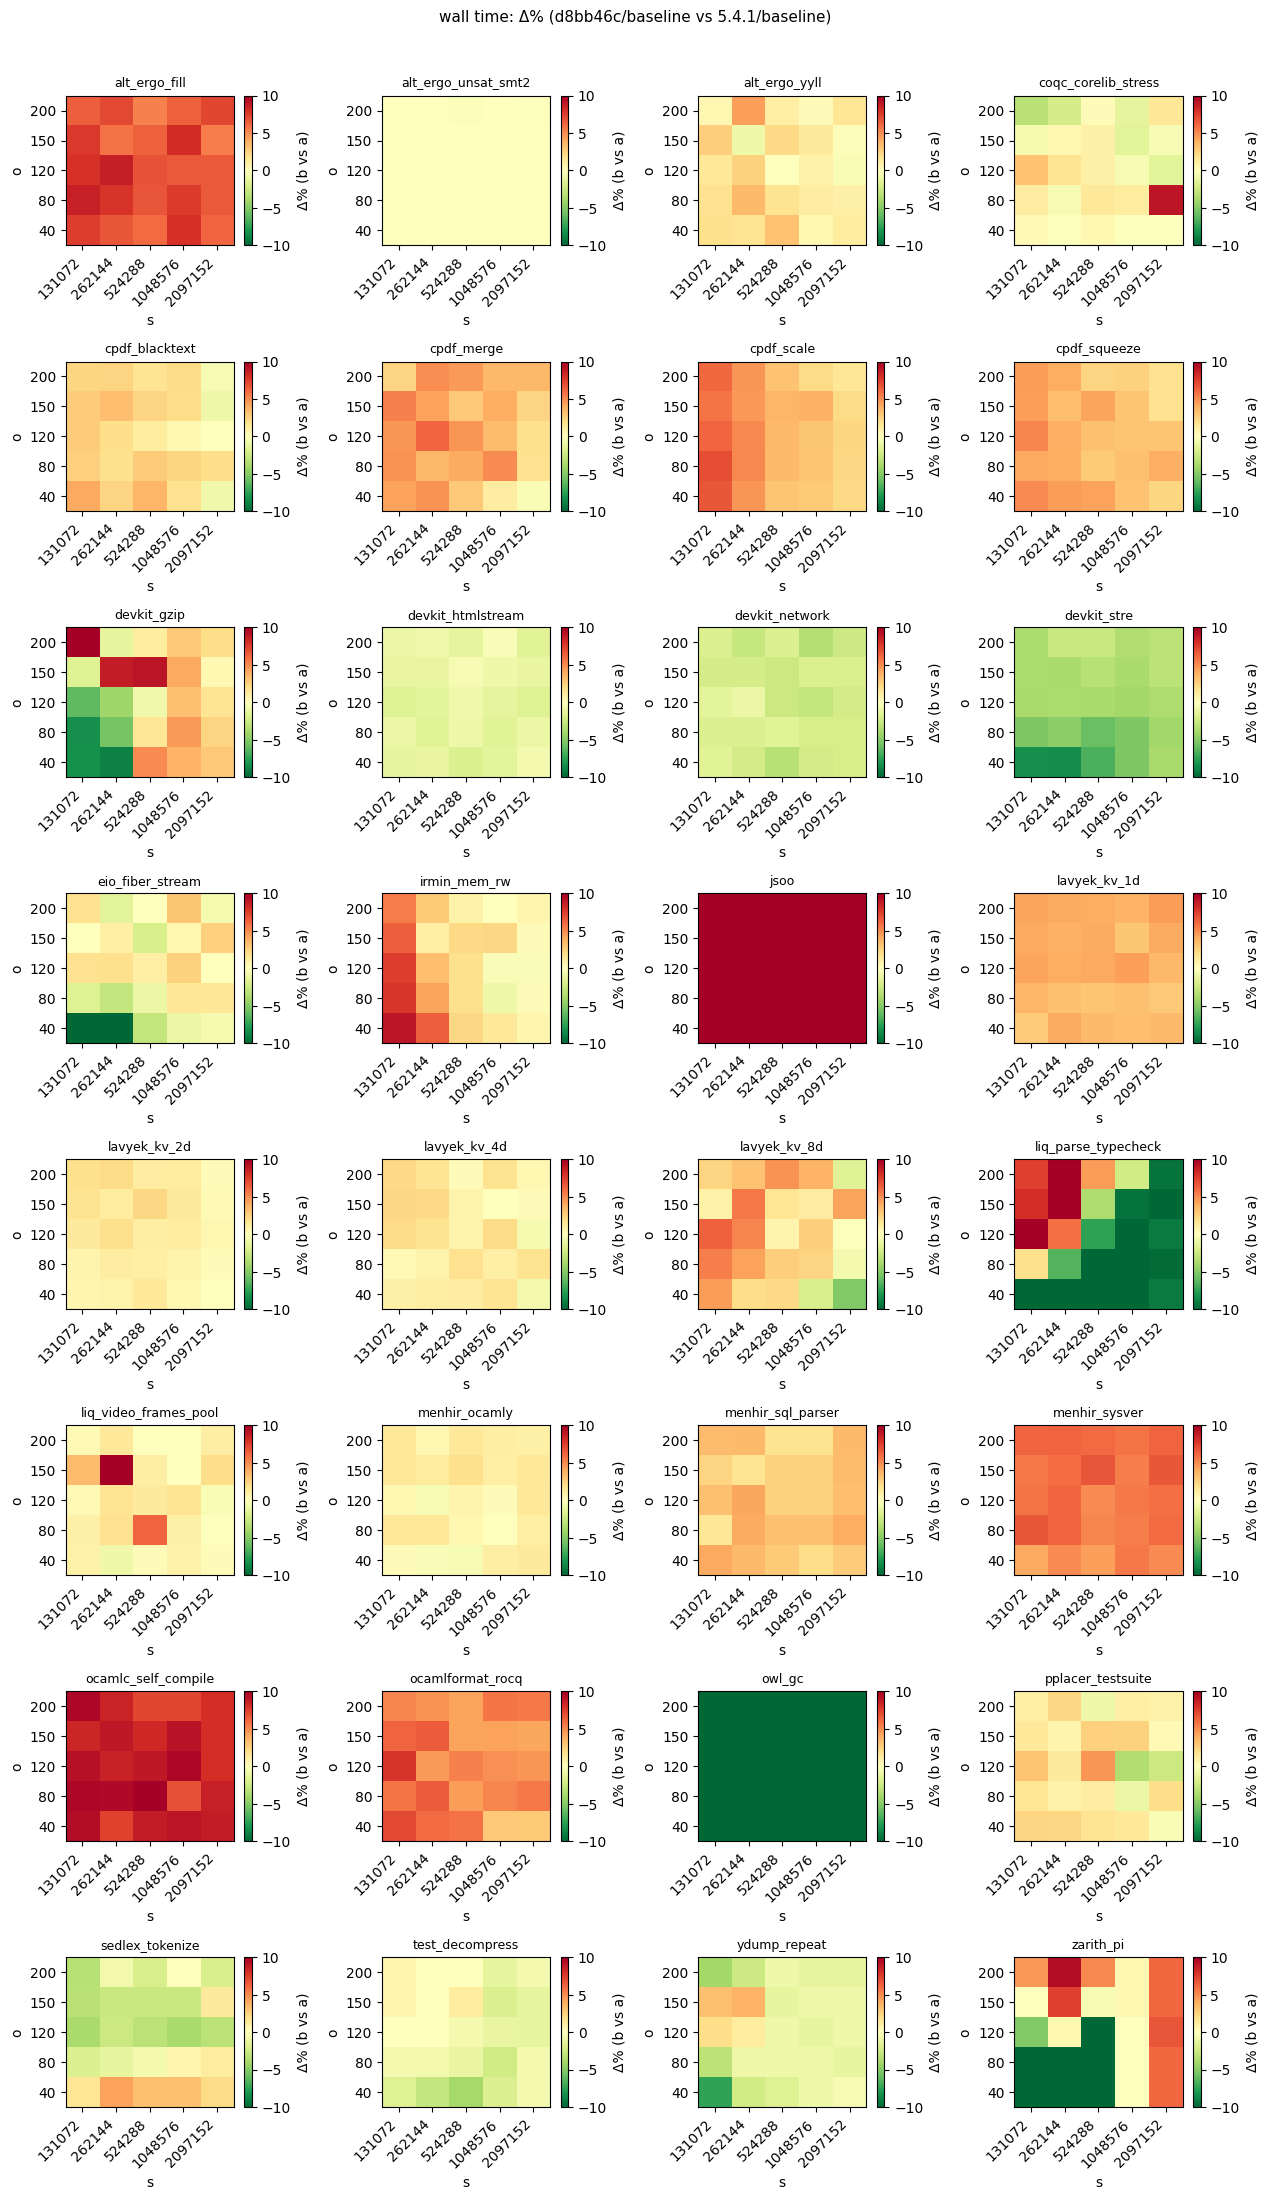

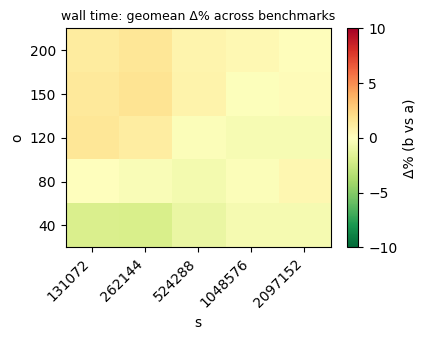

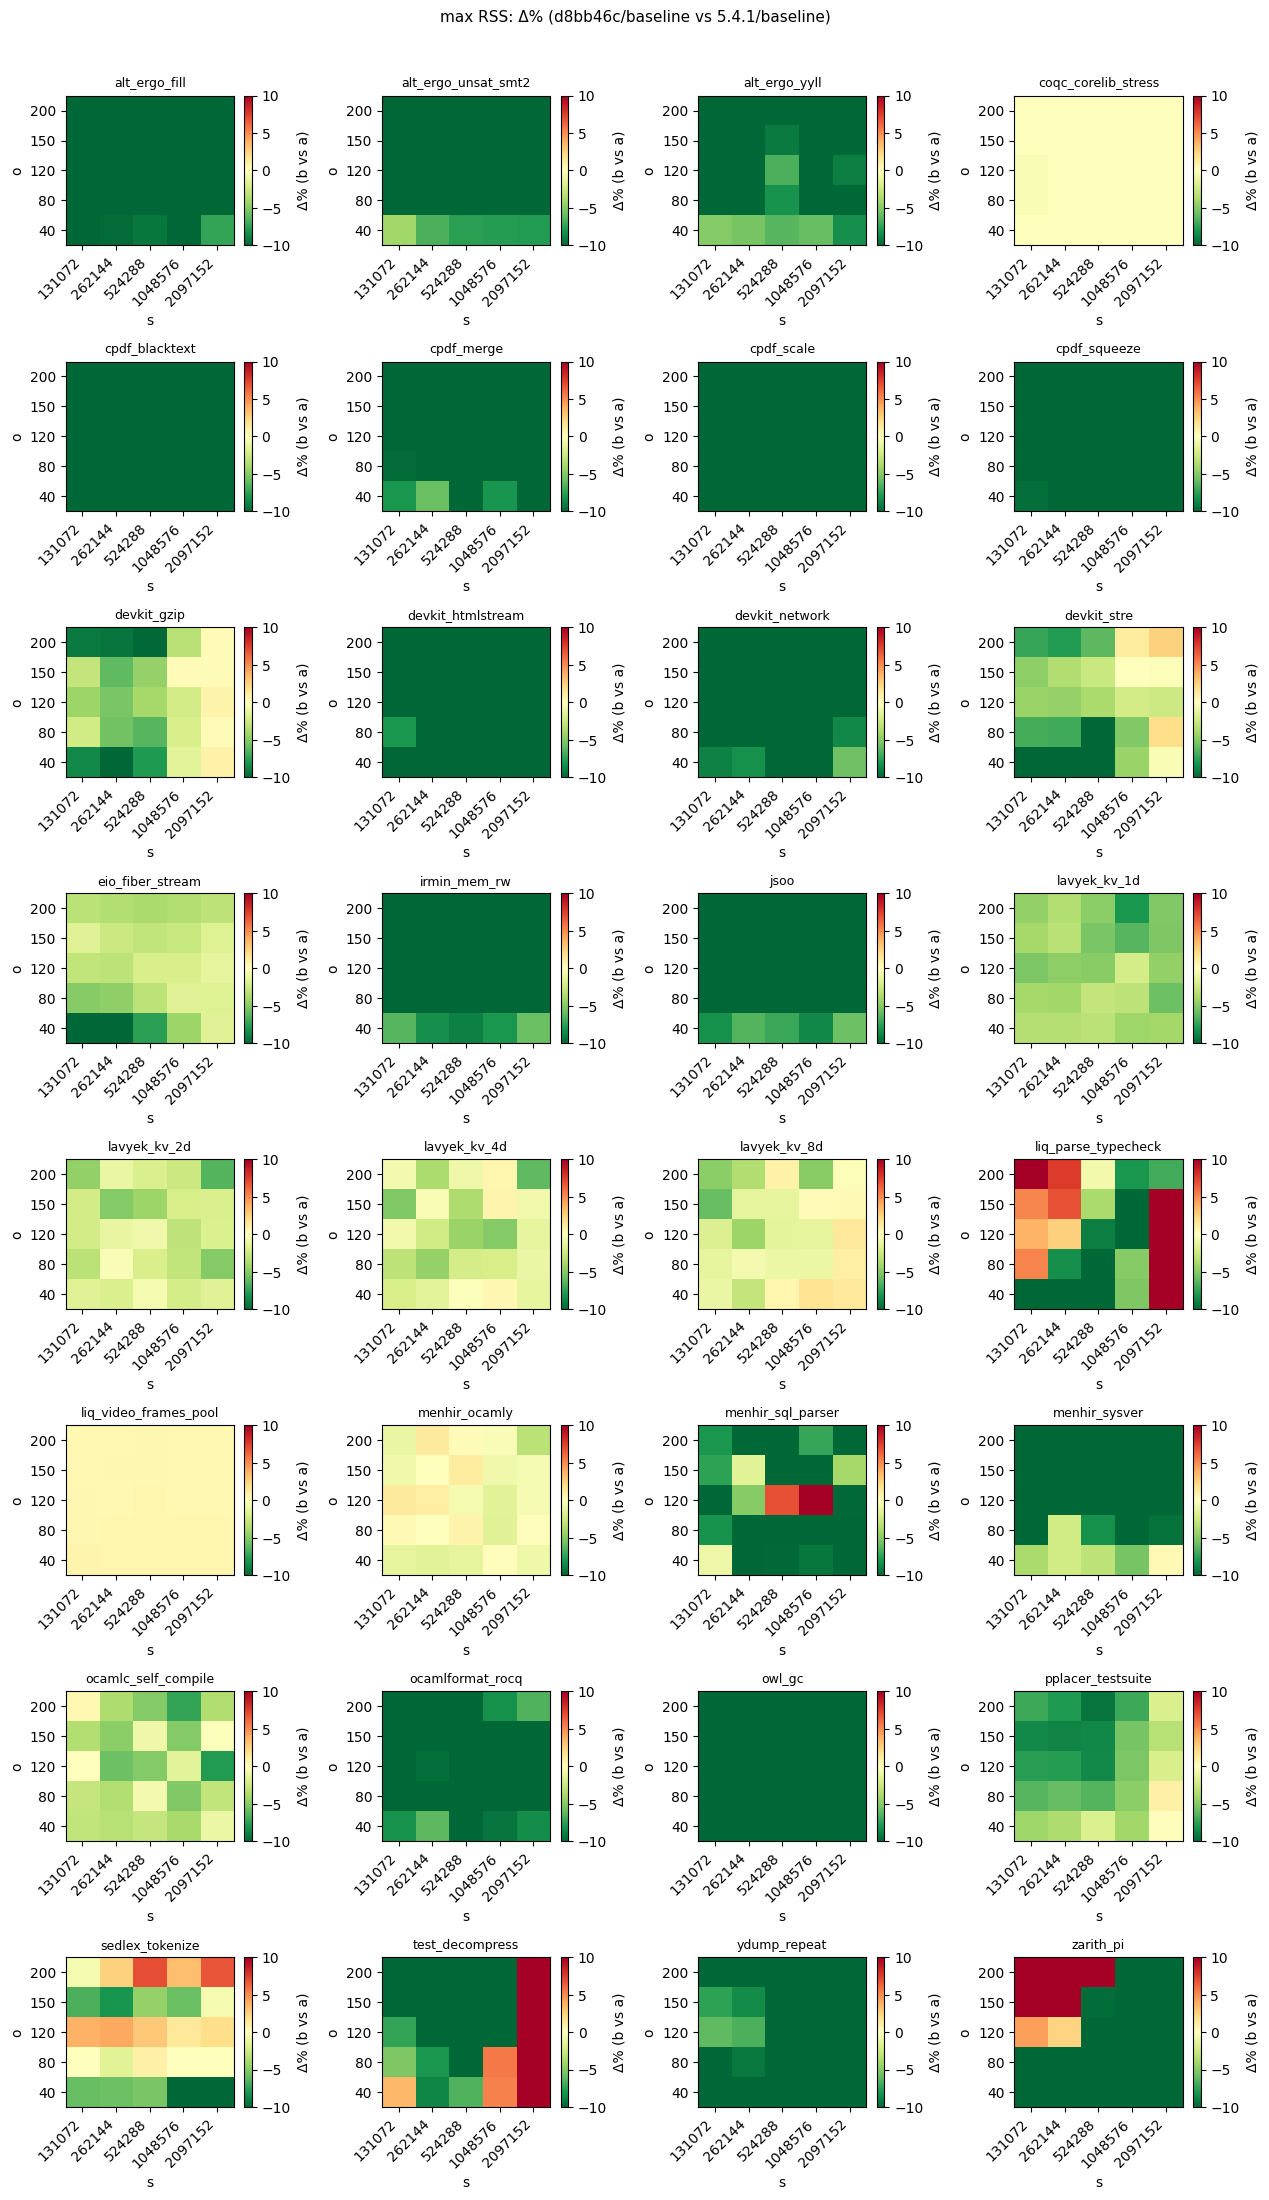

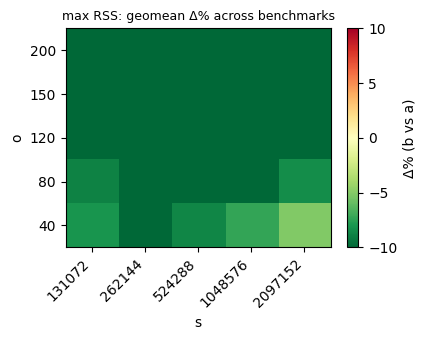

In [8]:
def _diverging_pcm(ax, grid: pd.DataFrame, title: str, xlabel: str, ylabel: str,
                   max_abs_pct: float):
    z = grid.to_numpy(dtype=float)
    norm = mcolors.TwoSlopeNorm(vmin=-max_abs_pct, vcenter=0.0, vmax=max_abs_pct)
    pcm = ax.imshow(z, origin="lower", aspect="auto",
                    cmap="RdYlGn_r", norm=norm)
    ax.set_xticks(range(len(grid.columns)))
    ax.set_xticklabels([str(int(c)) for c in grid.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(grid.index)))
    ax.set_yticklabels([str(int(r)) for r in grid.index])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=9)
    plt.colorbar(pcm, ax=ax, label="Δ% (b vs a)")


def render_cross_runtime(df: pd.DataFrame, comparisons) -> list[dict]:
    """Render Δ% heatmaps for every pair in every comparison block.

    Returns a list of long-form summary records suitable for CSV export.
    """
    export_rows: list[dict] = []
    for comp in comparisons:
        display(Markdown(f"### Comparison block: *{comp.label}*"))
        if not comp.pairs:
            display(Markdown("*(no pairs after resolution)*"))
            continue
        for av, bv in comp.pairs:
            sub_a = df[df["variant"] == av]
            sub_b = df[df["variant"] == bv]
            # Iterate per axis-presence pattern shared by both sides.
            pres_a = {tuple(c for c in GC_AXES if pd.notna(r[c])) for _, r in sub_a[GC_AXES].iterrows()}
            pres_b = {tuple(c for c in GC_AXES if pd.notna(r[c])) for _, r in sub_b[GC_AXES].iterrows()}
            for presence in sorted(pres_a & pres_b):
                if not presence:
                    continue
                pa = sub_a[sub_a[GC_AXES].apply(lambda r: tuple(c for c in GC_AXES if pd.notna(r[c])), axis=1) == presence]
                pb = sub_b[sub_b[GC_AXES].apply(lambda r: tuple(c for c in GC_AXES if pd.notna(r[c])), axis=1) == presence]
                # Pick varying axes for THIS sub-sweep (use both sides together).
                combined = pd.concat([pa, pb])
                varying = [c for c in presence if combined[c].nunique() > 1]
                if len(varying) < 1:
                    continue
                chosen, pin_vals = _heatmap_axes(combined, varying)
                if pin_vals:
                    for k, v in pin_vals.items():
                        pa = pa[pa[k] == v]
                        pb = pb[pb[k] == v]

                display(Markdown(
                    f"#### `{av}` → `{bv}` — axes {list(presence)} "
                    f"(plotted on {chosen}"
                    + (f", pinned {pin_vals}" if pin_vals else "")
                    + ")"
                ))

                for metric, label in [
                    ("olly_wall_time_s", "wall time"),
                    ("max_rss_mb",       "max RSS"),
                ]:
                    med_a = _aggregate(pa, chosen, metric).rename(columns={metric: "val_a"})
                    med_b = _aggregate(pb, chosen, metric).rename(columns={metric: "val_b"})
                    pair  = med_a.merge(med_b, on=["benchmark", *chosen], how="inner")
                    if pair.empty:
                        continue
                    pair["delta_pct"] = (pair["val_b"] / pair["val_a"] - 1.0) * 100.0

                    benches_p = sorted(pair["benchmark"].unique())
                    n = len(benches_p)
                    ncols = min(4, n)
                    nrows = (n + ncols - 1) // ncols
                    fig, axes = plt.subplots(nrows, ncols,
                                             figsize=(ncols * 3.2, nrows * 2.8),
                                             squeeze=False)
                    fig.suptitle(f"{label}: Δ% ({bv} vs {av})", fontsize=11)
                    for i, bench in enumerate(benches_p):
                        r, c = divmod(i, ncols)
                        ax = axes[r][c]
                        cell = pair[pair["benchmark"] == bench]
                        if len(chosen) == 1:
                            x = cell[chosen[0]].to_numpy()
                            y = cell["delta_pct"].to_numpy()
                            order = np.argsort(x)
                            ax.axhline(0.0, color="gray", lw=0.5)
                            ax.plot(x[order], y[order], "o-")
                            ax.set_xlabel(chosen[0])
                            ax.set_ylabel("Δ% (b vs a)")
                            ax.set_title(bench, fontsize=9)
                            continue
                        grid = cell.pivot(index=chosen[1], columns=chosen[0],
                                          values="delta_pct").sort_index().sort_index(axis=1)
                        _diverging_pcm(ax, grid, bench, chosen[0], chosen[1], MAX_PCT)

                        # Summary line per benchmark
                        wins = (grid < 0).sum().sum()
                        losses = (grid > 0).sum().sum()
                        best  = grid.min().min()
                        worst = grid.max().max()
                        export_rows.append({
                            "comparison": comp.label,
                            "a": av, "b": bv,
                            "axes": ",".join(presence),
                            "metric": label,
                            "benchmark": bench,
                            "cells_b_better": int(wins),
                            "cells_b_worse":  int(losses),
                            "best_pct":  round(float(best),  2),
                            "worst_pct": round(float(worst), 2),
                        })
                    for j in range(n, nrows * ncols):
                        r, c = divmod(j, ncols)
                        axes[r][c].set_axis_off()
                    fig.tight_layout(rect=[0, 0, 1, 0.97])
                    plt.show()

                    # Aggregate Δ%: geomean of ratios across benchmarks per config.
                    pair["log_ratio"] = np.log(pair["val_b"] / pair["val_a"])
                    agg = (pair.groupby(chosen, as_index=False)["log_ratio"]
                                .mean())
                    agg["geo_delta_pct"] = (np.exp(agg["log_ratio"]) - 1.0) * 100.0
                    if len(chosen) == 2:
                        grid = agg.pivot(index=chosen[1], columns=chosen[0],
                                         values="geo_delta_pct").sort_index().sort_index(axis=1)
                        fig, ax = plt.subplots(figsize=(4.5, 3.5))
                        _diverging_pcm(ax, grid,
                                       f"{label}: geomean Δ% across benchmarks",
                                       chosen[0], chosen[1], MAX_PCT)
                        fig.tight_layout()
                        plt.show()
    return export_rows


variants_in_df = set(df["variant"].unique())
comparisons = load_comparisons(LOGS_DIR, variants_in_df, baseline=BASELINE,
                               override=COMPARISONS_OVERRIDE)
print("Resolved comparison blocks:")
for c in comparisons:
    print(f"  - {c.label}: {c.pairs}")

cross_rows = render_cross_runtime(df, comparisons)

## 6. Export

Writes four CSVs to `cache/`:

- `gc_sweep_intra_default.csv` — the §3 Q1 long-form table, one row per
  (variant, sub-sweep, benchmark, cell, metric) with Δ% vs default.
- `gc_sweep_q3_candidates.csv` — every candidate cell from §4 Q3, with
  geomean wall/RSS/Pareto pct, worst per-bench pct + bench names, and
  improve/regress counts. Pass-the-safety-filter flag included.
- `gc_sweep_best_configs.csv` — the §4 Q3 picks: 3 rows per (variant,
  sub-sweep, filter ∈ {unfiltered, safe}), one each for
  {best wall, best RSS, best Pareto}.
- `gc_sweep_cross_runtime.csv` — the §5 Q2 long-form table, one row per
  (comparison, pair, sub-sweep, metric, benchmark).

In [ ]:
outdir = CACHE.parent
outdir.mkdir(exist_ok=True)

# §3 Q1: per-(bench, cell, metric) intra-default ratios
if intra_rows:
    p = outdir / "gc_sweep_intra_default.csv"
    pd.DataFrame(intra_rows).to_csv(p, index=False)
    print("wrote", p)

# §4 Q3: every candidate cell, plus picks
if q3_blocks:
    cand_rows = []
    pick_rows = []
    for blk in q3_blocks:
        meta = dict(
            variant=blk["variant"],
            axes=",".join(blk["presence"]),
            varying=",".join(blk["varying"]),
            fixed=";".join(f"{k}={int(v)}" for k, v in blk["fixed"].items()) or "",
            default_cell=blk["default_cell"],
        )
        # All candidates (with a safe-flag column)
        all_c = blk["all_cells"].copy()
        threshold = blk["threshold"]
        all_c["passes_safety_filter"] = all_c.apply(
            lambda r: (r["worst_wall_pct"] <= threshold
                       and r["worst_rss_pct"] <= threshold), axis=1)
        all_c["max_regression_threshold_pct"] = threshold
        for col, val in meta.items():
            all_c[col] = val
        cand_rows.append(all_c)

        # Picks (unfiltered and safe)
        for filter_name, df in [("unfiltered", blk["unfiltered_picks"]),
                                 ("safe",       blk["safe_picks"])]:
            if df is None or len(df) == 0:
                continue
            pf = df.copy()
            pf["filter"] = filter_name
            for col, val in meta.items():
                pf[col] = val
            pick_rows.append(pf)

    if cand_rows:
        p = outdir / "gc_sweep_q3_candidates.csv"
        pd.concat(cand_rows, ignore_index=True).to_csv(p, index=False)
        print("wrote", p)
    if pick_rows:
        p = outdir / "gc_sweep_best_configs.csv"
        pd.concat(pick_rows, ignore_index=True).to_csv(p, index=False)
        print("wrote", p)

# §5 Q2: cross-runtime
if cross_rows:
    p = outdir / "gc_sweep_cross_runtime.csv"
    pd.DataFrame(cross_rows).to_csv(p, index=False)
    print("wrote", p)
